# Análisis de la serie Total mensual de viajeros internacionales

Serie obligatoria del laboratorio: total mensual de visitantes internacionales a
Guatemala, enero 2009 – junio 2026 (210 meses).

Todo diagnóstico (estacionariedad, órdenes del modelo, hiperparámetros) se realiza
sobre el **conjunto de entrenamiento**. El conjunto de prueba se reserva
exclusivamente para la evaluación final.

## 1. Carga de los datos y construcción de la serie

### 1.1 Importación de librerías y lectura de la base

In [48]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (13, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 110
})

RUTA_DATOS = Path("../data/raw/Base_Migracion_2009-2026jun.xlsx")
assert RUTA_DATOS.exists(), f"No se encontró {RUTA_DATOS.resolve()}"

datos_raw = pd.read_excel(RUTA_DATOS, sheet_name="Datos")

datos = datos_raw.copy()
datos["Fecha"] = pd.to_datetime(
    dict(year=datos["Año"], month=datos["Mes cod"], day=1),
    errors="coerce"
)
datos = datos.sort_values("Fecha").reset_index(drop=True)

# Calendario completo de meses: asegura frecuencia mensual regular al reindexar.
meses_esperados = pd.date_range(
    datos["Fecha"].min(), datos["Fecha"].max(), freq="MS"
)

print(f"Registros:      {len(datos):,}")
print(f"Periodo:        {datos['Fecha'].min():%Y-%m} a {datos['Fecha'].max():%Y-%m} "
      f"({len(meses_esperados)} meses)")
print(f"Meses ausentes: {len(meses_esperados.difference(datos['Fecha'].unique()))}")
print(f"Fechas nulas:   {datos['Fecha'].isna().sum()}")
display(datos.head(3))

Registros:      161,036
Periodo:        2009-01 a 2026-06 (210 meses)
Meses ausentes: 0
Fechas nulas:   0


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.00,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.00,2009-01-01


### 1.2 Criterio de comparabilidad: filtros aplicados

Se aplican **dos** filtros, ambos por comparabilidad temporal y no por criterio
conceptual. La fuente cambia de metodología en 2023 y sin estos filtros la serie
mezclaría universos distintos:

1. **`Tipo de Viajero` ∈ {Turista, Excursionista}.** Se excluyen `Cruceristas`
   (deja de reportarse desde 2023) y `Viajero` (se reclasifica y pierde ~70% de
   nivel en 2023). Ninguno de los dos quiebres corresponde a un cambio real del
   turismo.
2. **`País` ≠ `Guatemala`.** La etiqueta `Guatemala` (residentes que reingresan al
   país) representa entre 34% y 48% del total hasta 2022 y **desaparece por
   completo desde enero de 2023**, sin ser reabsorbida por ninguna otra agrupación.
   Mantenerla introduciría un quiebre de nivel dentro del conjunto de prueba.

La evidencia de ambos quiebres se documenta en la celda siguiente.

In [49]:
# ---------------------------------------------------------------------------
# Quiebre 1: la columna "Tipo de Viajero"
# ---------------------------------------------------------------------------
quiebre_tipo = datos.pivot_table(
    index="Año", columns="Tipo de Viajero", values="Viajero",
    aggfunc="sum", fill_value=0
)

print("Quiebre 1 — totales anuales por Tipo de Viajero")
display(quiebre_tipo.loc[2019:])

# ---------------------------------------------------------------------------
# Quiebre 2: la etiqueta "Guatemala" dentro de la columna "País"
# Se evalúa ya con el filtro de tipo aplicado, que es el universo relevante.
# ---------------------------------------------------------------------------
visitantes_todo_pais = datos.loc[
    datos["Tipo de Viajero"].isin(["Turista", "Excursionista"])
]

total_anual = visitantes_todo_pais.groupby("Año")["Viajero"].sum()
gt_anual = (
    visitantes_todo_pais.loc[visitantes_todo_pais["País"] == "Guatemala"]
                        .groupby("Año")["Viajero"]
                        .sum()
                        .reindex(total_anual.index, fill_value=0)
)

quiebre_pais = pd.DataFrame({
    "Total (Turista + Excursionista)": total_anual,
    "Etiqueta 'Guatemala'": gt_anual,
    "% del total": 100 * gt_anual / total_anual
})

print("\nQuiebre 2 — peso anual de la etiqueta 'Guatemala'")
display(quiebre_pais)

etiquetas_2023 = sorted(
    visitantes_todo_pais.loc[visitantes_todo_pais["Año"] >= 2023, "País"].unique()
)
print(f"\nEtiquetas de 'País' presentes desde 2023 ({len(etiquetas_2023)}):")
print(", ".join(etiquetas_2023))
print(f"\n¿'Guatemala' aparece desde 2023?: {'Guatemala' in etiquetas_2023}")

Quiebre 1 — totales anuales por Tipo de Viajero


Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Año,,,,
2019,"130,789.00","1,081,250.85","3,050,999.75","428,780.60"
2020,"41,992.00","262,573.14","797,197.29","164,577.71"
2021,"3,908.00","82,470.05","1,016,494.33","164,895.39"
2022,"26,030.00","550,371.00","2,678,957.60","1,060,805.80"
2023,0.00,"793,847.06","2,123,979.75","330,882.19"
2024,0.00,"833,527.49","2,440,908.51","319,440.00"
2025,0.00,"811,391.52","2,540,897.14","244,949.34"
2026,0.00,"345,939.38","1,230,680.10","106,016.52"



Quiebre 2 — peso anual de la etiqueta 'Guatemala'


,Total (Turista + Excursionista),Etiqueta 'Guatemala',% del total
Año,,,
2009,"1,880,182.85","650,682.75",34.61
2010,"2,004,784.00","693,639.38",34.60
2011,"2,079,714.60","717,712.45",34.51
2012,"2,139,541.48","721,106.49",33.70
2013,"2,289,702.75","845,736.86",36.94
2014,"2,660,177.32","991,887.70",37.29
2015,"2,917,886.04","1,129,942.29",38.72
2016,"2,997,026.74","1,194,555.66",39.86
2017,"3,307,651.29","1,323,495.14",40.01



Etiquetas de 'País' presentes desde 2023 (26):
Alemania, Argentina, Australia, Belice, Brasil, Canadá, China, Colombia, Costa Rica, El Salvador, España, Estados Unidos de América, Federación de Rusia, Francia, Honduras, Israel, Italia, Japón, México, Nicaragua, Otros Países de América del Sur, Otros Países de Europa, Panamá, Países Bajos, Reino Unido de Gran Bretaña e Irlanda del Norte, Resto del Mundo

¿'Guatemala' aparece desde 2023?: False


La tabla confirma que cruceristas y viajeros son dos etiquetas que por sanidad de los datos tuvieron que ser descartadas debido a falta de datos apartir de 2023. Tambien la etiqueta de "Guatemala" fue descartada dado que la serie pedia visitantes internacionales.

### 1.3 Construcción de la serie total mensual

Se agrega por mes y se reindexa sobre los 210 meses del calendario para garantizar
frecuencia mensual regular (`MS`), requisito de la descomposición, las pruebas de
raíz unitaria y el modelado.

Filas usadas:   132,894 de 161,036
Observaciones:  210  |  NaN: 0  |  freq: <MonthBegin>
Acumulado:      32,841,522


,Visitantes
count,210.00
mean,"156,388.20"
std,"74,176.33"
min,0.00
25%,"110,282.64"
50%,"146,394.81"
75%,"205,989.87"
max,"365,573.02"


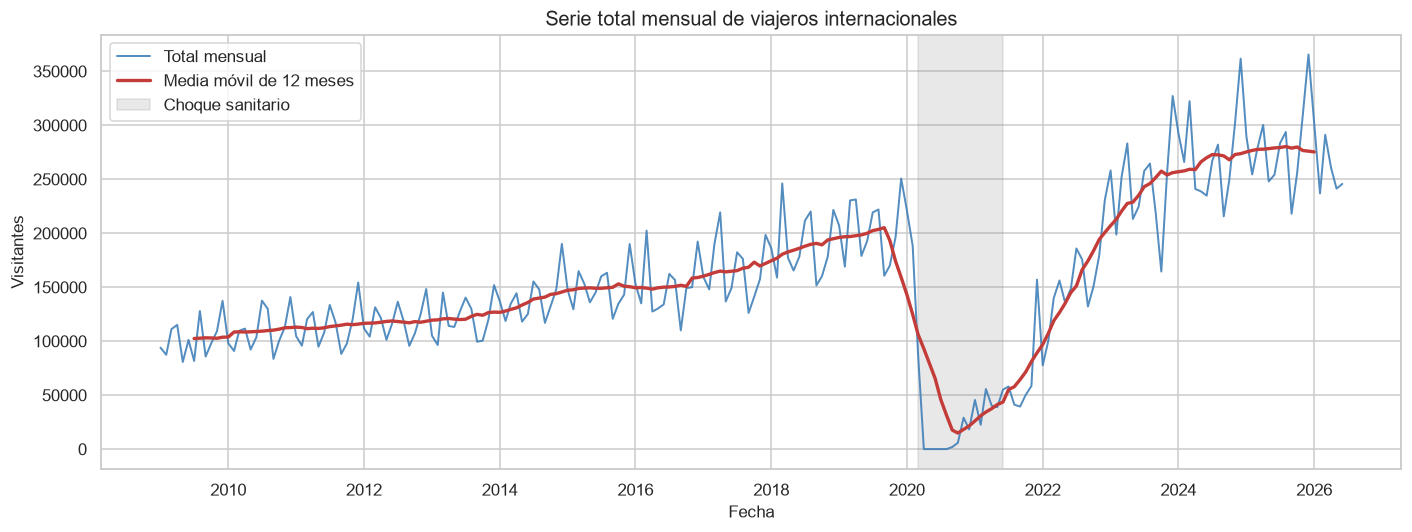

In [50]:
TIPOS_COMPARABLES = ["Turista", "Excursionista"]
PAIS_EXCLUIDO = "Guatemala"

visitantes = datos.loc[
    datos["Tipo de Viajero"].isin(TIPOS_COMPARABLES)
    & (datos["País"] != PAIS_EXCLUIDO)
].copy()

serie_total = (
    visitantes.groupby("Fecha")["Viajero"]
              .sum()
              .reindex(meses_esperados, fill_value=0)
              .rename("Total")
              .asfreq("MS")          # deja la frecuencia explícita en el índice
)
serie_total.index.name = "Fecha"

print(f"Filas usadas:   {len(visitantes):,} de {len(datos):,}")
print(f"Observaciones:  {len(serie_total)}  |  NaN: {serie_total.isna().sum()}  "
      f"|  freq: {serie_total.index.freq}")
print(f"Acumulado:      {serie_total.sum():,.0f}")
display(serie_total.describe().to_frame("Visitantes"))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_total, color="#3679B5", lw=1.3, alpha=0.85, label="Total mensual")
ax.plot(serie_total.rolling(12, center=True).mean(),
        color="#C43C39", lw=2.2, label="Media móvil de 12 meses")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
           color="gray", alpha=0.18, label="Choque sanitario")
ax.set(
    title="Serie total mensual de viajeros internacionales",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend()
plt.tight_layout()
plt.show()

A simple vista se puede ver que existe una tendencia creciente de los visitantes internacionales en Guatemala, claramente por el emergencia sanitaria del 2020 se ve que hay un pico donde toda entrada internacional en guatemala fue practicamente nula, sin embargo luego de eso siguio la tendencia creciente.

### 1.4 Comparación con la serie sin filtrar

Se grafican ambas versiones (con y sin `Guatemala`) para dimensionar el efecto del
filtro y dejar documentado el quiebre.

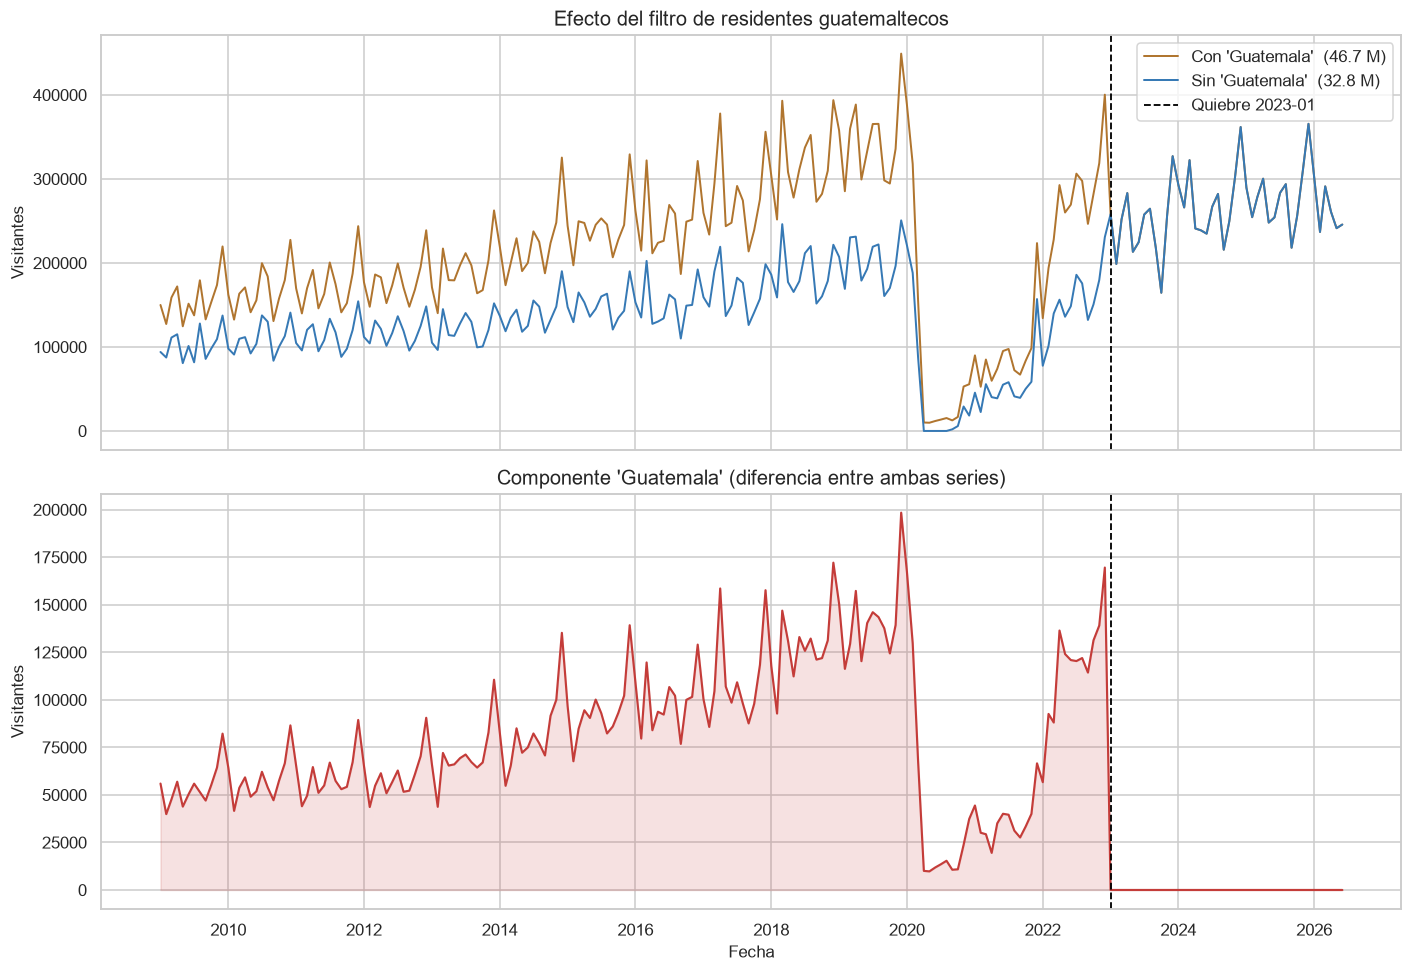

,Meses,Con GT — nivel,Con GT — índice 2019=100,Sin GT — nivel,Sin GT — índice 2019=100
Año,,,,,
2009,12,"1,880,182.85",45.50,"1,229,500.10",50.62
2010,12,"2,004,784.00",48.52,"1,311,144.62",53.98
2011,12,"2,079,714.60",50.33,"1,362,002.15",56.08
2012,12,"2,139,541.48",51.78,"1,418,434.99",58.40
2013,12,"2,289,702.75",55.41,"1,443,965.89",59.45
2014,12,"2,660,177.32",64.38,"1,668,289.62",68.69
2015,12,"2,917,886.04",70.61,"1,787,943.75",73.61
2016,12,"2,997,026.74",72.53,"1,802,471.08",74.21
2017,12,"3,307,651.29",80.04,"1,984,156.14",81.69


Primer mes con componente 'Guatemala' = 0: 2023-01
Meses con componente = 0: 42 de 210
Peso medio del componente antes de 2023: 38.7%

Nota: 2026 cubre solo enero–junio, su nivel anual no es comparable.


In [51]:
# Serie con la etiqueta "Guatemala" incluida: es la definición usada en los
# notebooks previos del laboratorio y sirve como contraste.
serie_con_gt = (
    datos.loc[datos["Tipo de Viajero"].isin(TIPOS_COMPARABLES)]
         .groupby("Fecha")["Viajero"]
         .sum()
         .reindex(meses_esperados, fill_value=0)
         .rename("Con Guatemala")
         .asfreq("MS")
)
componente_gt = (serie_con_gt - serie_total).rename("Componente 'Guatemala'")

INICIO_QUIEBRE = pd.Timestamp("2023-01-01")

# ---------------------------------------------------------------------------
# Gráfico: ambas series y la diferencia entre ellas
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(serie_con_gt, color="#B0752F", lw=1.3,
             label="Con 'Guatemala'  (46.7 M)")
axes[0].plot(serie_total, color="#3679B5", lw=1.3,
             label="Sin 'Guatemala'  (32.8 M)")
axes[0].axvline(INICIO_QUIEBRE, color="black", ls="--", lw=1.2,
                label="Quiebre 2023-01")
axes[0].set(title="Efecto del filtro de residentes guatemaltecos",
            ylabel="Visitantes")
axes[0].legend()

axes[1].plot(componente_gt, color="#C43C39", lw=1.4)
axes[1].axvline(INICIO_QUIEBRE, color="black", ls="--", lw=1.2)
axes[1].fill_between(componente_gt.index, componente_gt.values,
                     color="#C43C39", alpha=0.15)
axes[1].set(title="Componente 'Guatemala' (diferencia entre ambas series)",
            xlabel="Fecha", ylabel="Visitantes")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Cuantificación: la comparación contra 2019 cambia según qué serie se use
# ---------------------------------------------------------------------------
anual = pd.DataFrame({
    "Con GT — nivel": serie_con_gt.resample("YS").sum(),
    "Sin GT — nivel": serie_total.resample("YS").sum(),
    "Meses": serie_total.resample("YS").count()
})
anual.index = anual.index.year
anual.index.name = "Año"
anual["Con GT — índice 2019=100"] = (
    100 * anual["Con GT — nivel"] / anual.loc[2019, "Con GT — nivel"]
)
anual["Sin GT — índice 2019=100"] = (
    100 * anual["Sin GT — nivel"] / anual.loc[2019, "Sin GT — nivel"]
)

display(anual[["Meses", "Con GT — nivel", "Con GT — índice 2019=100",
               "Sin GT — nivel", "Sin GT — índice 2019=100"]])

# ---------------------------------------------------------------------------
# Verificación del quiebre
# ---------------------------------------------------------------------------
primer_cero = componente_gt[componente_gt == 0].index.min()
print(f"Primer mes con componente 'Guatemala' = 0: {primer_cero:%Y-%m}")
print(f"Meses con componente = 0: {(componente_gt == 0).sum()} de {len(componente_gt)}")
print(f"Peso medio del componente antes de 2023: "
      f"{100 * (componente_gt[:INICIO_QUIEBRE].sum() / serie_con_gt[:INICIO_QUIEBRE].sum()):.1f}%")
print("\nNota: 2026 cubre solo enero–junio, su nivel anual no es comparable.")

La comparación deja ver que guatemala representa una gran parte de los datos, por lo que comparado con los datos crudos esta serie baja la cantidad de personas, pero es por el gran porcentaje de Guatemala

## 2. División 70 – 30 de los datos (en orden cronológico)

Al tratarse de una serie de tiempo, la partición **no puede ser aleatoria**: se
toma el 70% inicial de los meses para entrenamiento y el 30% final para prueba.
Mezclar meses futuros en el entrenamiento produciría fuga de información y una
evaluación optimista.

,Inicio,Fin,Frecuencia,Meses,% de meses,Media,Desv. estándar,Mínimo,Máximo
Conjunto,,,,,,,,,
Entrenamiento,2009-01-01,2021-03-01,MS,147,70.00,"131,754.98","51,473.56",0.00,"250,685.07"
Prueba,2021-04-01,2026-06-01,MS,63,30.00,"213,865.71","86,675.50","38,823.00","365,573.02"


Fecha de corte:        2021-03
Sin traslape:          True
Cobertura completa:    210 de 210 meses
Ceros en entrenamiento: 5  |  en prueba: 0

Media de los últimos 12 meses de entrenamiento:     14,908
Media del conjunto de prueba:                      213,866
Razón prueba / final de entrenamiento:               14.35x


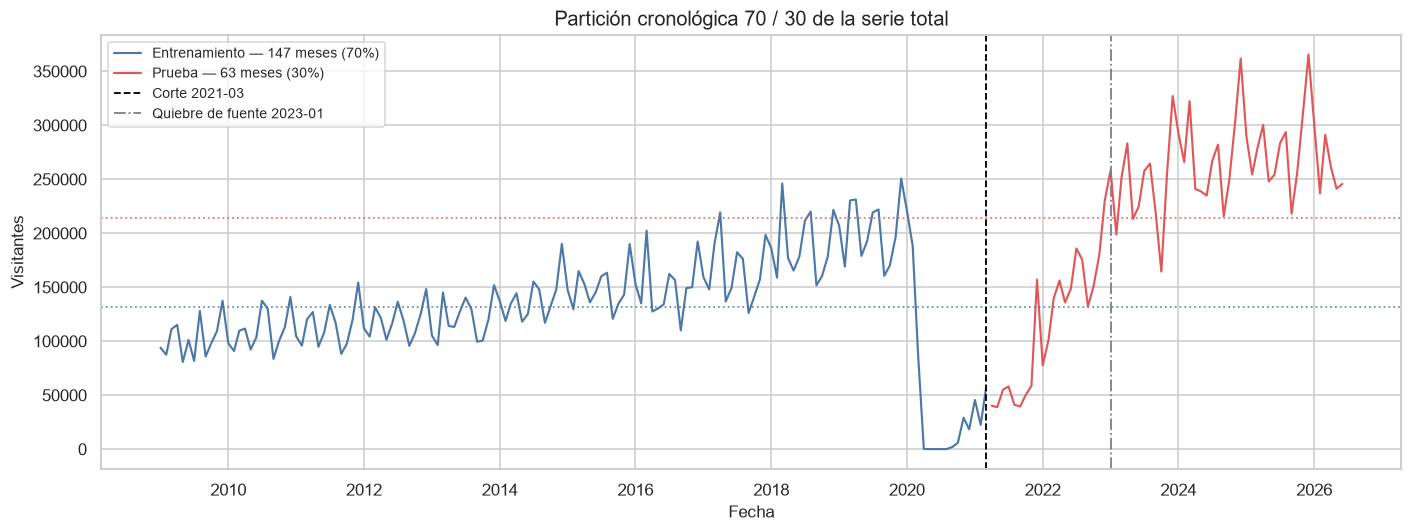

In [52]:
# La partición se hace sobre el ÍNDICE DE LA SERIE (210 meses del calendario) y no
# sobre las fechas presentes en el detalle: tras el filtro, abr–ago 2020 no tienen
# ninguna fila (cero visitantes no residentes). Partir sobre el detalle daría 205
# meses -> corte 143/62, perdiendo 5 meses en silencio y desplazando la fecha de corte.
n_train = int(np.floor(0.70 * len(serie_total)))

serie_train = serie_total.iloc[:n_train]
serie_test = serie_total.iloc[n_train:]
FECHA_CORTE = serie_train.index[-1]

particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Inicio": [serie_train.index.min(), serie_test.index.min()],
    "Fin": [serie_train.index.max(), serie_test.index.max()],
    "Frecuencia": [serie_train.index.freqstr, serie_test.index.freqstr],
    "Meses": [len(serie_train), len(serie_test)],
    "% de meses": [
        100 * len(serie_train) / len(serie_total),
        100 * len(serie_test) / len(serie_total)
    ],
    "Media": [serie_train.mean(), serie_test.mean()],
    "Desv. estándar": [serie_train.std(), serie_test.std()],
    "Mínimo": [serie_train.min(), serie_test.min()],
    "Máximo": [serie_train.max(), serie_test.max()]
}).set_index("Conjunto")

display(particion)

# ---------------------------------------------------------------------------
# Verificaciones de la partición
# ---------------------------------------------------------------------------
print(f"Fecha de corte:        {FECHA_CORTE:%Y-%m}")
print(f"Sin traslape:          {serie_train.index.max() < serie_test.index.min()}")
print(f"Cobertura completa:    {len(serie_train) + len(serie_test)} de {len(serie_total)} meses")
print(f"Ceros en entrenamiento: {(serie_train == 0).sum()}  |  en prueba: {(serie_test == 0).sum()}")

# Magnitud del cambio de régimen que el modelo deberá atravesar
print(f"\nMedia de los últimos 12 meses de entrenamiento: {serie_train.tail(12).mean():>10,.0f}")
print(f"Media del conjunto de prueba:                   {serie_test.mean():>10,.0f}")
print(f"Razón prueba / final de entrenamiento:          {serie_test.mean() / serie_train.tail(12).mean():>10,.2f}x")

# ---------------------------------------------------------------------------
# Gráfico de la partición
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(serie_train, color="#4C78A8", lw=1.4,
        label=f"Entrenamiento — {len(serie_train)} meses (70%)")
ax.plot(serie_test, color="#E15759", lw=1.4,
        label=f"Prueba — {len(serie_test)} meses (30%)")

ax.axhline(serie_train.mean(), color="#4C78A8", ls=":", lw=1.2, alpha=0.8)
ax.axhline(serie_test.mean(), color="#E15759", ls=":", lw=1.2, alpha=0.8)
ax.axvline(FECHA_CORTE, color="black", ls="--", lw=1.2,
           label=f"Corte {FECHA_CORTE:%Y-%m}")
ax.axvline(INICIO_QUIEBRE, color="gray", ls="-.", lw=1.2,
           label="Quiebre de fuente 2023-01")

ax.set(
    title="Partición cronológica 70 / 30 de la serie total",
    xlabel="Fecha",
    ylabel="Visitantes"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

| Conjunto | Inicio | Fin | Frecuencia | Meses | % |
|---|---|---|---|---|---|
| Entrenamiento | 2009-01 | 2021-03 | Mensual (`MS`) | 147 | 70.00% |
| Prueba | 2021-04 | 2026-06 | Mensual (`MS`) | 63 | 30.00% |

A simple vista se puede ver donde exactamente es donde se hace el corte para train y test, el piso de la pandemia puede ser algo que comprometa los sigueintes pasos pero veremos como evolucionan esto.

## 3. Descomposición de la serie en sus componentes

La descomposición separa la serie en tendencia, estacionalidad y residuo, con
período 12 (estacionalidad anual).

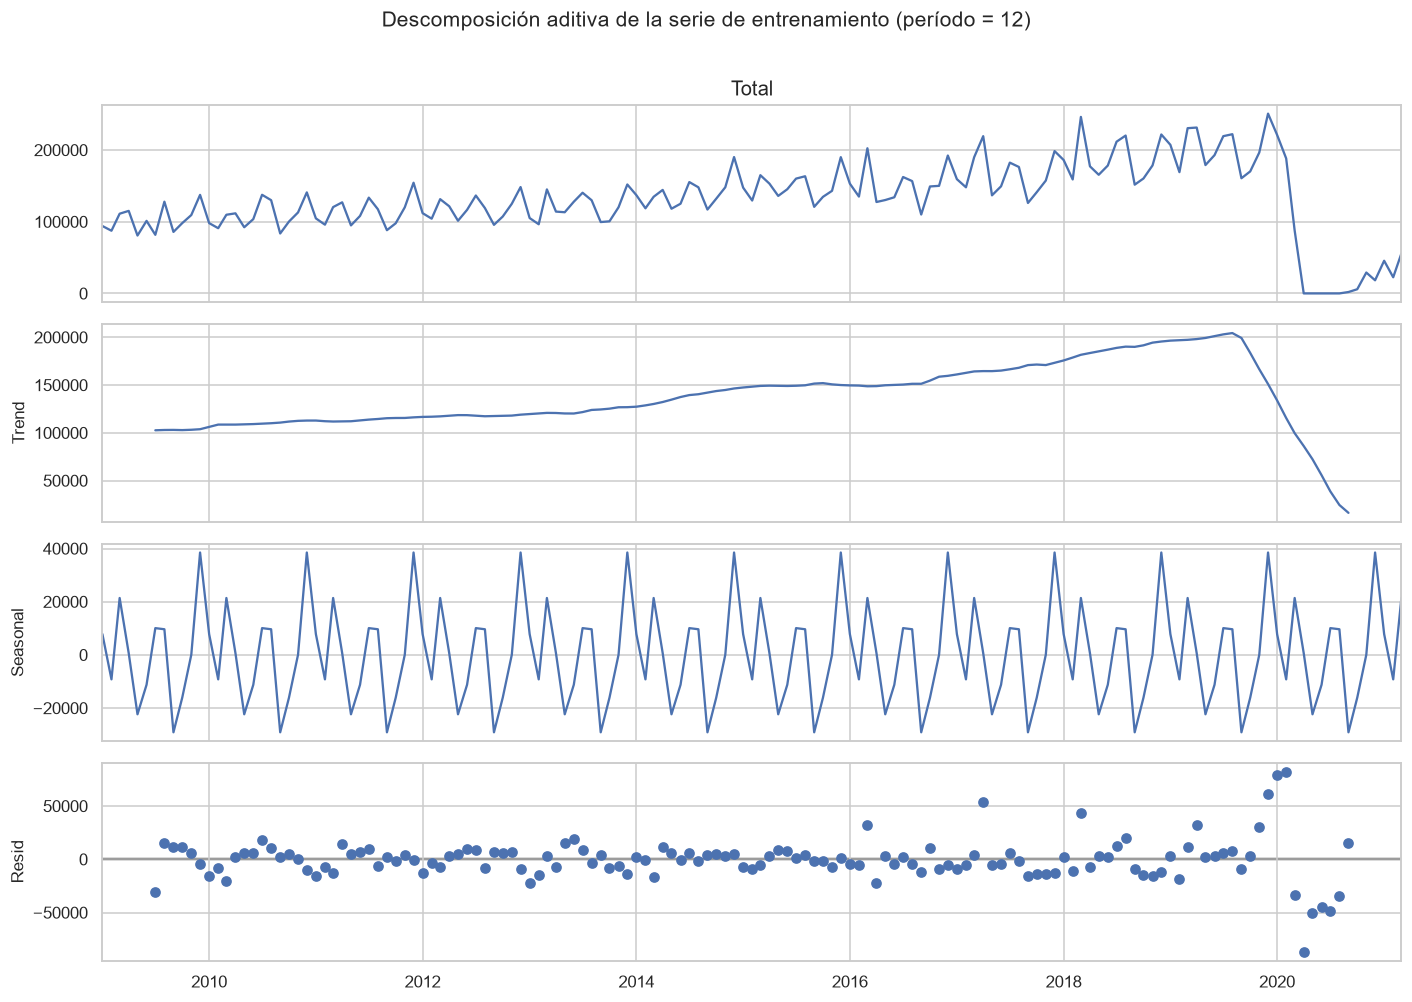

,Observado,Tendencia,Estacionalidad,Residuo
count,147.00,135.00,147.00,135.00
mean,"131,754.98","138,015.91",135.89,-156.84
std,"51,473.56","35,221.79","18,274.73","19,851.53"
min,0.00,"16,240.04","-29,127.08","-86,781.54"
25%,"104,852.15","115,368.96","-11,245.48","-8,671.80"
50%,"132,067.45","134,675.08",625.09,"1,532.56"
75%,"159,676.34","161,895.77","9,840.74","5,948.22"
max,"250,685.07","204,347.50","38,495.98","81,937.35"


Meses con tendencia calculable: 135 de 147 (2009-07 a 2020-09)
Error máximo de reconstrucción: 0.000000


In [53]:
PERIODO = 12

# Modelo ADITIVO: la serie contiene cinco meses en cero (abr–ago 2020), valores
# incompatibles con una descomposición multiplicativa (implicaría dividir por cero).
#
# NO se usa extrapolate_trend: la tendencia es una media móvil centrada de 12
# términos, de modo que los 6 meses de cada extremo no son calculables. Rellenarlos
# por extrapolación lineal prolongaría la pendiente del colapso de 2020 y produciría
# valores negativos, imposibles por construcción (el promedio de cantidades no
# negativas nunca lo es). Se prefiere dejarlos como NaN.
#
# La descomposición se calcula sobre el ENTRENAMIENTO, no sobre la serie completa.
descomposicion = seasonal_decompose(serie_train, model="additive", period=PERIODO)

fig = descomposicion.plot()
fig.set_size_inches(13, 9)
fig.suptitle(
    "Descomposición aditiva de la serie de entrenamiento (período = 12)",
    y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

componentes = pd.DataFrame({
    "Observado": descomposicion.observed,
    "Tendencia": descomposicion.trend,
    "Estacionalidad": descomposicion.seasonal,
    "Residuo": descomposicion.resid
})

display(componentes.describe())

# Cobertura efectiva tras descartar los extremos no calculables
validos = componentes["Tendencia"].dropna()
print(f"Meses con tendencia calculable: {len(validos)} de {len(serie_train)} "
      f"({validos.index.min():%Y-%m} a {validos.index.max():%Y-%m})")

# Verificación: en un modelo aditivo los tres componentes reconstruyen la serie.
reconstruida = (
    componentes["Tendencia"] + componentes["Estacionalidad"] + componentes["Residuo"]
)
print(f"Error máximo de reconstrucción: "
      f"{(reconstruida - serie_train).abs().max():.6f}")

### 3.1 Tendencia

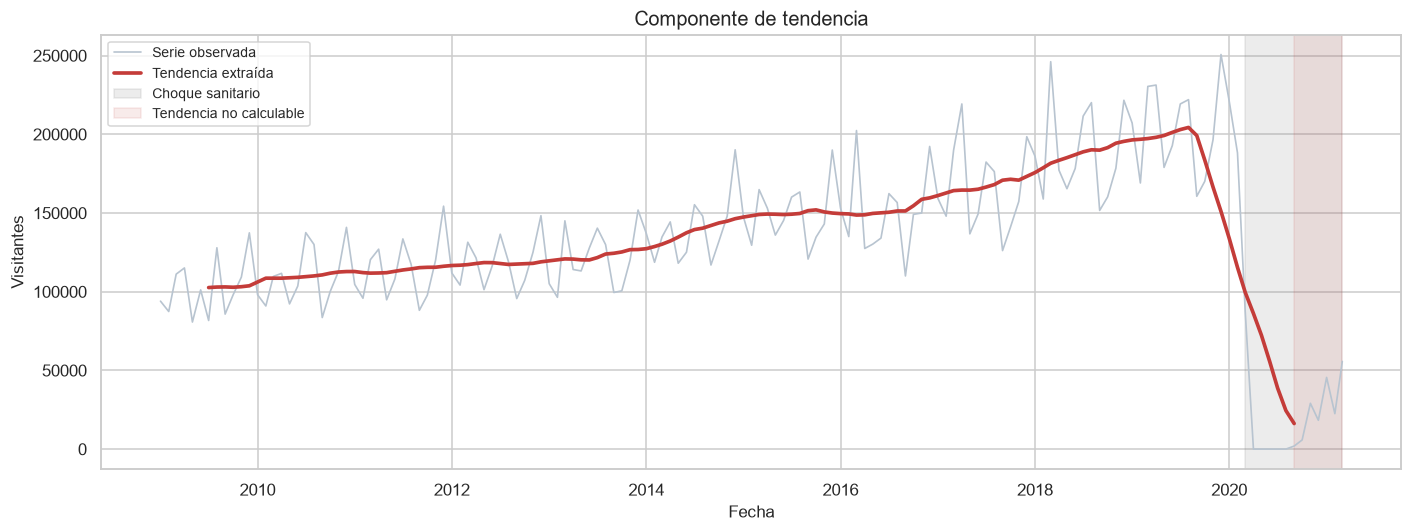

,Valor
Primer valor calculable,"102,627 (2009-07)"
Nivel pre-pandemia (última ventana limpia),"204,347 (2019-08)"
Valor máximo,"204,347 (2019-08)"
Último valor calculable,"16,240 (2020-09)"
Crecimiento inicio → pre-pandemia,+99.1%
Caída pre-pandemia → último calculable,-92.1%
Crecimiento anual compuesto (2009-07 → 2019-08),+7.1%


Fecha,2009-01-01,2010-01-01,2011-01-01,2012-01-01,2013-01-01,2014-01-01,2015-01-01,2016-01-01,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01
Tendencia media,"103,053.67","109,759.58","113,693.57","117,756.32","122,543.44","137,263.36","149,604.54","151,851.00","166,919.85","186,824.85","191,391.57","71,392.08",NaN


In [54]:
tendencia = descomposicion.trend
tendencia_valida = tendencia.dropna()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train, color="#B8C4D0", lw=1.1, label="Serie observada")
ax.plot(tendencia, color="#C43C39", lw=2.4, label="Tendencia extraída")
ax.axvspan(pd.Timestamp("2020-03-01"), serie_train.index.max(),
           color="gray", alpha=0.15, label="Choque sanitario")
ax.axvspan(tendencia_valida.index.max(), serie_train.index.max(),
           color="#C43C39", alpha=0.10, label="Tendencia no calculable")
ax.set(title="Componente de tendencia", xlabel="Fecha", ylabel="Visitantes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Referencia pre-pandemia: la tendencia en el mes t es una media móvil centrada que
# abarca de t-6 a t+6 (13 meses). Para que su ventana no incluya ningún mes del
# choque —que arranca en marzo de 2020— el centro debe ser como máximo agosto de
# 2019, cuya ventana termina en febrero de 2020. Usar diciembre de 2019 como
# referencia sería incorrecto: su ventana ya contiene tres meses de colapso y
# subestima el nivel previo a la pandemia.
PRE_PANDEMIA = pd.Timestamp("2019-08-01")

inicio = tendencia_valida.index[0]
anios = (PRE_PANDEMIA - inicio).days / 365.25
cagr = (tendencia.loc[PRE_PANDEMIA] / tendencia_valida.iloc[0]) ** (1 / anios) - 1

resumen_tendencia = pd.Series({
    "Primer valor calculable": f"{tendencia_valida.iloc[0]:,.0f}  ({inicio:%Y-%m})",
    "Nivel pre-pandemia (última ventana limpia)":
        f"{tendencia.loc[PRE_PANDEMIA]:,.0f}  ({PRE_PANDEMIA:%Y-%m})",
    "Valor máximo": f"{tendencia_valida.max():,.0f}  ({tendencia_valida.idxmax():%Y-%m})",
    "Último valor calculable":
        f"{tendencia_valida.iloc[-1]:,.0f}  ({tendencia_valida.index[-1]:%Y-%m})",
    "Crecimiento inicio → pre-pandemia":
        f"{100 * (tendencia.loc[PRE_PANDEMIA] / tendencia_valida.iloc[0] - 1):+.1f}%",
    "Caída pre-pandemia → último calculable":
        f"{100 * (tendencia_valida.iloc[-1] / tendencia.loc[PRE_PANDEMIA] - 1):+.1f}%",
    "Crecimiento anual compuesto (2009-07 → 2019-08)": f"{100 * cagr:+.1f}%"
}, name="Valor")

display(resumen_tendencia.to_frame())

# Nivel medio de la tendencia por año (NaN donde no hay meses calculables)
display(tendencia.resample("YS").mean().rename("Tendencia media").to_frame().T)

Como lo habiamos previsto desde antes, existe una tendencia clara de crecimiento que se detiene por la pandemia

### 3.2 Estacionalidad

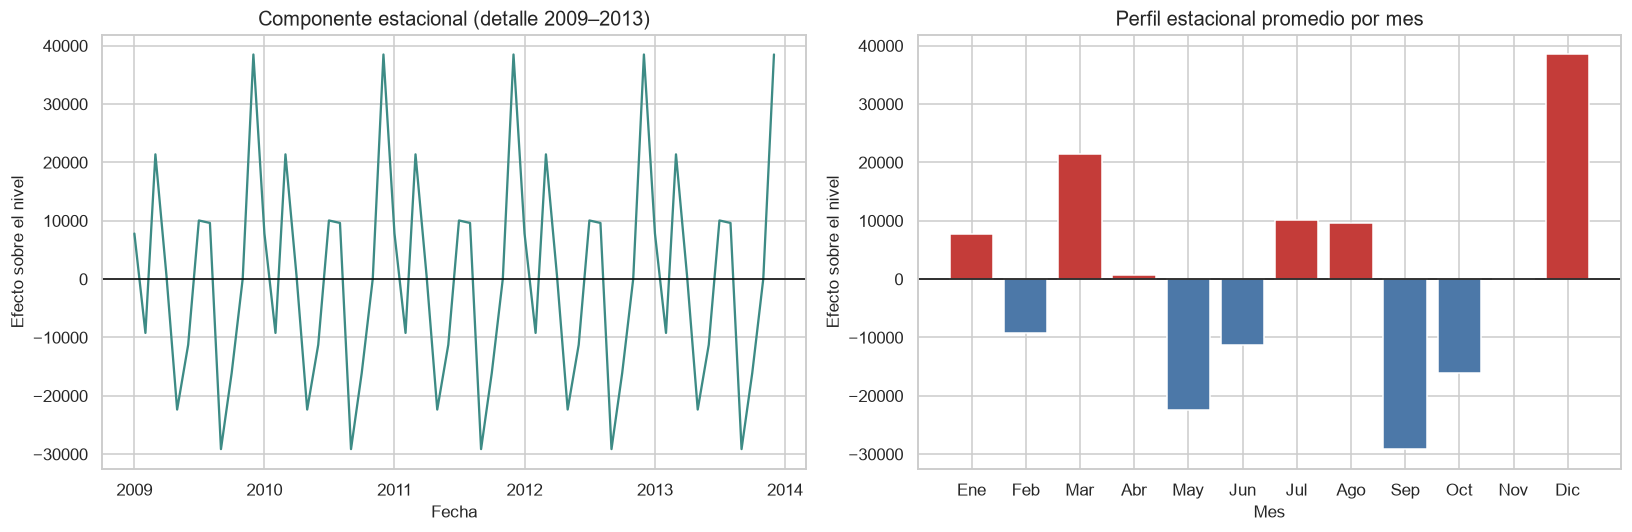

,Efecto estacional
Ene,"7,808.44"
Feb,"-9,217.88"
Mar,"21,385.71"
Abr,625.09
May,"-22,348.83"
Jun,"-11,245.48"
Jul,"10,054.47"
Ago,"9,627.01"
Sep,"-29,127.08"
Oct,"-16,108.67"


Amplitud estacional (máx − mín): 67,623 visitantes
Mes más alto: Dic (+38,496)
Mes más bajo: Sep (-29,127)
Amplitud como % de la media de la serie: 51.3%

¿El patrón se repite idéntico cada año?: True


In [55]:
estacional = descomposicion.seasonal

# El patrón estacional se repite idéntico cada 12 meses: basta un ciclo para
# caracterizarlo. Se ordena por mes calendario.
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

perfil = estacional.groupby(estacional.index.month).mean()
perfil.index = MESES
perfil.name = "Efecto estacional"

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(estacional.loc["2009":"2013"], color="#3D8B85", lw=1.5)
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="Componente estacional (detalle 2009–2013)",
            xlabel="Fecha", ylabel="Efecto sobre el nivel")

colores = ["#C43C39" if v > 0 else "#4C78A8" for v in perfil.values]
axes[1].bar(perfil.index, perfil.values, color=colores)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(title="Perfil estacional promedio por mes",
            xlabel="Mes", ylabel="Efecto sobre el nivel")

plt.tight_layout()
plt.show()

display(perfil.to_frame())

print(f"Amplitud estacional (máx − mín): {perfil.max() - perfil.min():,.0f} visitantes")
print(f"Mes más alto: {perfil.idxmax()} ({perfil.max():+,.0f})")
print(f"Mes más bajo: {perfil.idxmin()} ({perfil.min():+,.0f})")
print(f"Amplitud como % de la media de la serie: "
      f"{100 * (perfil.max() - perfil.min()) / serie_train.mean():.1f}%")
print(f"\n¿El patrón se repite idéntico cada año?: "
      f"{estacional.groupby(estacional.index.month).std().max() < 1e-6}")

Por lo que podemos ver que si existe una estacionalidad con picos claros en marzo y diciembre cada año.

### 3.3 Ruido (residuo)

Meses analizables: 135 de 147 (2009-07 a 2020-09)


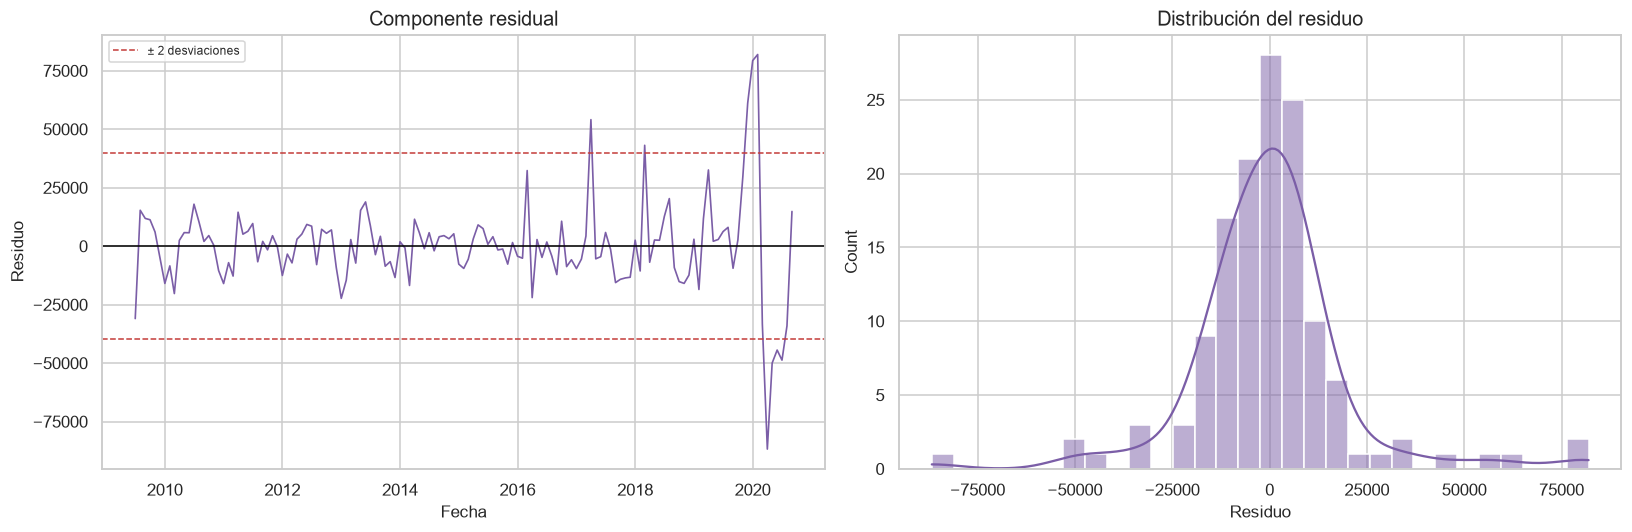

,Valor
Media,-156.84
Desviación estándar,"19,851.53"
Mínimo,"-86,781.54"
Máximo,"81,937.35"
Desv. del residuo / desv. de la serie (%),41.28
Meses fuera de ±2 desviaciones,9.00


Diez meses con mayor residuo en valor absoluto:


,Residuo
Fecha,
2020-04-01,"-86,781.54"
2020-02-01,"81,937.35"
2020-01-01,"79,322.80"
2019-12-01,"61,159.76"
2017-04-01,"54,090.39"
2020-05-01,"-49,988.98"
2020-07-01,"-48,743.63"
2020-06-01,"-44,436.70"
2018-03-01,"43,119.20"


In [56]:
residuo = descomposicion.resid.dropna()

print(f"Meses analizables: {len(residuo)} de {len(serie_train)} "
      f"({residuo.index.min():%Y-%m} a {residuo.index.max():%Y-%m})")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(residuo, color="#7B5EA7", lw=1.1)
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(2 * residuo.std(), color="#C43C39", ls="--", lw=1,
                label="± 2 desviaciones")
axes[0].axhline(-2 * residuo.std(), color="#C43C39", ls="--", lw=1)
axes[0].set(title="Componente residual", xlabel="Fecha", ylabel="Residuo")
axes[0].legend(fontsize=8)

sns.histplot(residuo, bins=30, kde=True, color="#7B5EA7", ax=axes[1])
axes[1].set(title="Distribución del residuo", xlabel="Residuo")

plt.tight_layout()
plt.show()

resumen_residuo = pd.Series({
    "Media": residuo.mean(),
    "Desviación estándar": residuo.std(),
    "Mínimo": residuo.min(),
    "Máximo": residuo.max(),
    "Desv. del residuo / desv. de la serie (%)":
        100 * residuo.std() / serie_train.loc[residuo.index].std(),
    "Meses fuera de ±2 desviaciones": int((residuo.abs() > 2 * residuo.std()).sum())
}, name="Valor")

display(resumen_residuo.to_frame())

print("Diez meses con mayor residuo en valor absoluto:")
orden = residuo.abs().sort_values(ascending=False).index[:10]
display(residuo.loc[orden].to_frame("Residuo"))

Se puede ver que los residuos se mantienen en linea dentro de varios años, sin embargo este residuo se dispara como ya vimos anteriormente por la pandemia

### 3.4 Fuerza de tendencia y de estacionalidad

Métricas normalizadas (0 a 1) que permiten comparar la importancia relativa de
cada componente sin depender de la escala de la serie.

In [57]:
def fuerza_componentes(descomp):
    """Fuerza de tendencia y estacionalidad (Hyndman & Athanasopoulos).

    F = max(0, 1 - Var(residuo) / Var(componente + residuo))

    Toma valores entre 0 y 1: cercano a 1 indica que el componente domina el
    comportamiento de la serie; cercano a 0, que es irrelevante frente al ruido.
    """
    resid = descomp.resid.dropna()
    trend = descomp.trend.reindex(resid.index)
    seas = descomp.seasonal.reindex(resid.index)
    fuerza_t = max(0.0, 1 - np.var(resid) / np.var(trend + resid))
    fuerza_s = max(0.0, 1 - np.var(resid) / np.var(seas + resid))
    return fuerza_t, fuerza_s


fuerza_t, fuerza_s = fuerza_componentes(descomposicion)

# Contraste: se repite el cálculo excluyendo el choque sanitario, para separar
# cuánto de la fuerza de tendencia proviene del colapso de 2020 y cuánto del
# crecimiento estructural previo. También sin extrapolar los extremos.
serie_pre_choque = serie_train.loc[:"2020-02-01"]
descomposicion_pre = seasonal_decompose(
    serie_pre_choque, model="additive", period=PERIODO
)
fuerza_t_pre, fuerza_s_pre = fuerza_componentes(descomposicion_pre)

fuerzas = pd.DataFrame(
    {
        "Meses de la serie": [len(serie_train), len(serie_pre_choque)],
        "Meses evaluables": [
            descomposicion.resid.notna().sum(),
            descomposicion_pre.resid.notna().sum()
        ],
        "Fuerza de tendencia": [fuerza_t, fuerza_t_pre],
        "Fuerza de estacionalidad": [fuerza_s, fuerza_s_pre]
    },
    index=[
        "Entrenamiento completo (2009-01 → 2021-03)",
        "Excluyendo el choque (2009-01 → 2020-02)"
    ]
)

display(fuerzas)

# Peso relativo de cada componente sobre la varianza observada, calculado sobre el
# mismo conjunto de meses evaluables para que las proporciones sean comparables.
idx = descomposicion.resid.dropna().index
varianzas = pd.Series({
    "Var(Tendencia) / Var(Observado)":
        np.var(descomposicion.trend.loc[idx]) / np.var(serie_train.loc[idx]),
    "Var(Estacionalidad) / Var(Observado)":
        np.var(descomposicion.seasonal.loc[idx]) / np.var(serie_train.loc[idx]),
    "Var(Residuo) / Var(Observado)":
        np.var(descomposicion.resid.loc[idx]) / np.var(serie_train.loc[idx])
}, name="Proporción")

display(varianzas.to_frame())

,Meses de la serie,Meses evaluables,Fuerza de tendencia,Fuerza de estacionalidad
Entrenamiento completo (2009-01 → 2021-03),147,135,0.80,0.46
Excluyendo el choque (2009-01 → 2020-02),134,122,0.88,0.73


,Proporción
Var(Tendencia) / Var(Observado),0.54
Var(Estacionalidad) / Var(Observado),0.15
Var(Residuo) / Var(Observado),0.17


Los valores obtenidos indican que la serie está **dominada por su tendencia** y que
posee un **ciclo anual real pero parcialmente enmascarado** por el choque sanitario.

La fuerza de la tendencia es de **0.80** con el bloque completo, lo que deja ver que la serie es claramente dominada por la tendencia creciente

La estacionalidad gracias a la pandemia baja a un **0.46** pero quitando esos datos sube drasticamente a **0.73**

## 4. ¿Es necesario transformar la serie?

Una serie es estacionaria (en sentido débil) si cumple tres condiciones:

1. **Media constante** en el tiempo.
2. **Varianza constante** en el tiempo.
3. **Autocovarianza estable**, dependiente solo del rezago y no del momento.

Cada criterio se evalúa por separado a continuación, sobre el conjunto de
entrenamiento.

### 4.1 Media constante

Se inspecciona la media móvil de 12 meses y se contrasta con dos pruebas formales
de hipótesis complementarias.

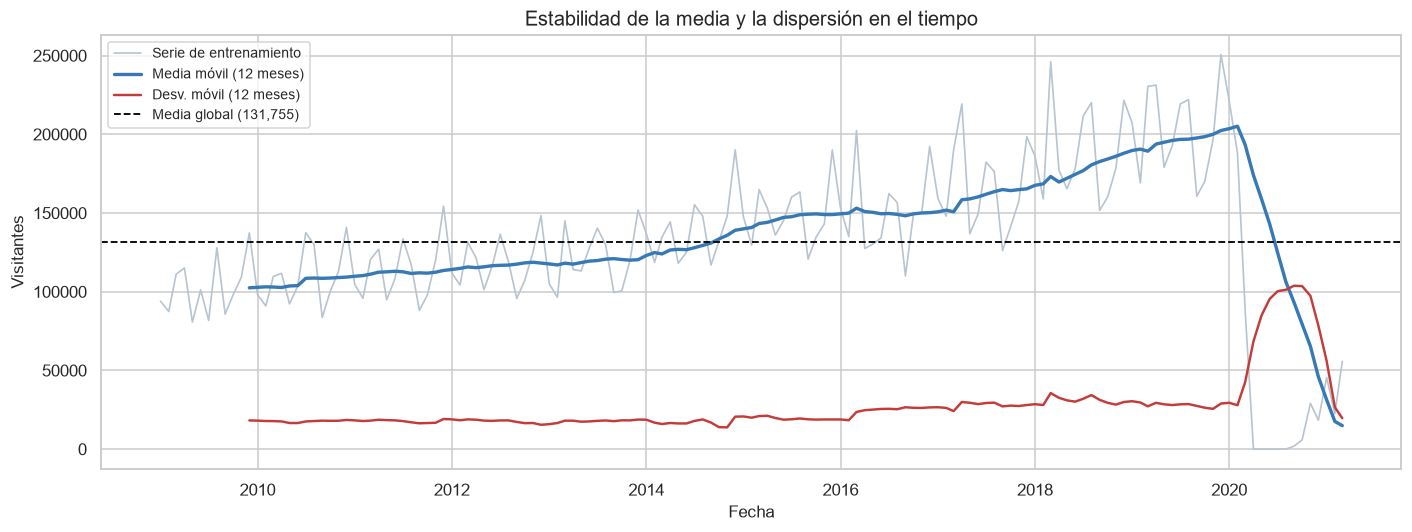

,Valor
Media global,"131,755"
Media móvil mínima,"14,908 (2021-03)"
Media móvil máxima,"205,144 (2020-02)"
Razón máx / mín,13.8x
Rango como % de la media global,144%


,Meses,Media,Desv. estándar
2009–2011,36,"108,406.86","18,656.70"
2012–2014,36,"125,852.51","20,230.29"
2015–2017,36,"154,849.19","25,191.59"
2018–2020,36,"145,453.48","87,198.61"
2021,3,"41,249.47","17,004.06"


In [58]:
VENTANA = 12

media_movil = serie_train.rolling(VENTANA).mean()
desv_movil = serie_train.rolling(VENTANA).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train, color="#B8C4D0", lw=1.1, label="Serie de entrenamiento")
ax.plot(media_movil, color="#3679B5", lw=2.2, label=f"Media móvil ({VENTANA} meses)")
ax.plot(desv_movil, color="#C43C39", lw=1.6, label=f"Desv. móvil ({VENTANA} meses)")
ax.axhline(serie_train.mean(), color="black", ls="--", lw=1.2,
           label=f"Media global ({serie_train.mean():,.0f})")
ax.set(title="Estabilidad de la media y la dispersión en el tiempo",
       xlabel="Fecha", ylabel="Visitantes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Si la media fuera constante, la media móvil oscilaría estrechamente alrededor de
# la media global. Se cuantifica cuánto se aparta.
mm = media_movil.dropna()
resumen_media = pd.Series({
    "Media global": f"{serie_train.mean():,.0f}",
    "Media móvil mínima": f"{mm.min():,.0f}  ({mm.idxmin():%Y-%m})",
    "Media móvil máxima": f"{mm.max():,.0f}  ({mm.idxmax():%Y-%m})",
    "Razón máx / mín": f"{mm.max() / mm.min():,.1f}x",
    "Rango como % de la media global": f"{100 * (mm.max() - mm.min()) / serie_train.mean():.0f}%"
}, name="Valor")

display(resumen_media.to_frame())

# Media por bloques de tres años, como lectura complementaria
bloques = serie_train.groupby(
    pd.cut(serie_train.index.year, bins=[2008, 2011, 2014, 2017, 2020, 2022])
).agg(["count", "mean", "std"])
bloques.index = ["2009–2011", "2012–2014", "2015–2017", "2018–2020", "2021"]
bloques.columns = ["Meses", "Media", "Desv. estándar"]
display(bloques)

La media móvil deja ver que la media no se mantiene constante ocn el tiempo, lo que puede dar un primer vistazo a que necesitaremos metodos para volver a hacer estacionaria la seire

#### Prueba ADF (Dickey–Fuller aumentada)

H0: la serie tiene raíz unitaria (**no** es estacionaria).
Un p-valor menor a 0.05 permite **rechazar** H0 y aporta evidencia de estacionariedad.

In [59]:
def prueba_adf(serie, etiqueta, regresion="c"):
    """Dickey–Fuller aumentada.

    H0: la serie tiene raíz unitaria (NO es estacionaria).
    p < 0.05 -> se rechaza H0 -> evidencia de estacionariedad.

    regresion="c"  : contrasta contra una media constante.
    regresion="ct" : permite además una tendencia determinista, apropiado cuando
                     la serie crece de forma sostenida.
    """
    limpia = pd.Series(serie).dropna()
    estadistico, pvalor, rezagos, nobs, criticos, _ = adfuller(
        limpia, autolag="AIC", regression=regresion
    )
    return {
        "Serie": etiqueta,
        "Especificación": "Constante" if regresion == "c" else "Constante + tendencia",
        "Estadístico ADF": estadistico,
        "p-valor": pvalor,
        "Rezagos": rezagos,
        "Observaciones": nobs,
        "Crítico 5%": criticos["5%"],
        "¿Estacionaria al 5%?": pvalor < 0.05
    }


# Se contrasta también la serie pre-choque: el colapso de 2020 devuelve la serie a
# niveles bajos y puede alterar el resultado de las pruebas de raíz unitaria.
resultados_adf = pd.DataFrame([
    prueba_adf(serie_train, "Entrenamiento completo", "c"),
    prueba_adf(serie_train, "Entrenamiento completo", "ct"),
    prueba_adf(serie_pre_choque, "Excluyendo el choque", "c"),
    prueba_adf(serie_pre_choque, "Excluyendo el choque", "ct")
]).set_index(["Serie", "Especificación"])

display(resultados_adf)

print("Regla de decisión: se rechaza H0 (raíz unitaria) si el estadístico ADF es")
print("MENOR que el valor crítico, o equivalentemente si el p-valor < 0.05.")

Estadístico ADF  p-valor  \
Serie                  Especificación                                    
Entrenamiento completo Constante                        -2.30     0.17   
                       Constante + tendencia            -3.97     0.01   
Excluyendo el choque   Constante                         1.91     1.00   
                       Constante + tendencia            -0.82     0.96   

                                              Rezagos  Observaciones  \
Serie                  Especificación                                  
Entrenamiento completo Constante                   14            132   
                       Constante + tendencia       13            133   
Excluyendo el choque   Constante                   13            120   
                       Constante + tendencia       13            120   

                                              Crítico 5%  ¿Estacionaria al 5%?  
Serie                  Especificación                                           
Entrenamiento completo Constante                   -2.88                 False  
                       Constante + tendencia       -3.44                  True  
Excluyendo el choque   Constante                   -2.89                 False  
                       Constante + tendencia       -3.45                 False

Regla de decisión: se rechaza H0 (raíz unitaria) si el estadístico ADF es
MENOR que el valor crítico, o equivalentemente si el p-valor < 0.05.


Podemos ver que solamente con el entrenamiento completo de la constante mas la tendencia se logra pasar el test ADF pero en todos los demas falla, por lo que nos deja ver desde ya que necesitaremos tecnicas para transfomrar los datos.

#### Prueba KPSS

H0: la serie **es** estacionaria (en torno a un nivel o una tendencia).
Es la hipótesis contraria a ADF, por lo que aquí un p-valor menor a 0.05 lleva a
**rechazar** la estacionariedad. Usar ambas pruebas evita conclusiones ambiguas.

In [60]:
def prueba_kpss(serie, etiqueta, regresion="c"):
    """KPSS (Kwiatkowski–Phillips–Schmidt–Shin).

    H0: la serie ES estacionaria (contraria a la de ADF).
    p < 0.05 -> se rechaza H0 -> evidencia de NO estacionariedad.

    regresion="c"  : estacionariedad en torno a un nivel.
    regresion="ct" : estacionariedad en torno a una tendencia determinista.

    Nota: statsmodels interpola el p-valor sobre una tabla y lo acota al rango
    [0.01, 0.10]. Un p de 0.10 debe leerse como ">= 0.10" y uno de 0.01 como
    "<= 0.01"; conviene comparar el estadístico contra los valores críticos.
    """
    limpia = pd.Series(serie).dropna()
    estadistico, pvalor, rezagos, criticos = kpss(
        limpia, regression=regresion, nlags="auto"
    )
    return {
        "Serie": etiqueta,
        "Especificación": "Nivel" if regresion == "c" else "Tendencia",
        "Estadístico KPSS": estadistico,
        "p-valor": pvalor,
        "Rezagos": rezagos,
        "Crítico 5%": criticos["5%"],
        "¿Estacionaria al 5%?": estadistico < criticos["5%"]
    }


resultados_kpss = pd.DataFrame([
    prueba_kpss(serie_train, "Entrenamiento completo", "c"),
    prueba_kpss(serie_train, "Entrenamiento completo", "ct"),
    prueba_kpss(serie_pre_choque, "Excluyendo el choque", "c"),
    prueba_kpss(serie_pre_choque, "Excluyendo el choque", "ct")
]).set_index(["Serie", "Especificación"])

display(resultados_kpss)

# ---------------------------------------------------------------------------
# Lectura conjunta. La decisión de modelado se toma sobre serie_train, que es lo
# que efectivamente se ajusta; la serie pre-choque sirve como contexto.
# ---------------------------------------------------------------------------
combinada = pd.DataFrame({
    "ADF — ¿estacionaria?": resultados_adf["¿Estacionaria al 5%?"],
    "ADF — p": resultados_adf["p-valor"]
})
combinada["KPSS — ¿estacionaria?"] = resultados_kpss["¿Estacionaria al 5%?"].values
combinada["KPSS — estadístico"] = resultados_kpss["Estadístico KPSS"].values

display(combinada)

adf_c = bool(resultados_adf.loc[("Entrenamiento completo", "Constante"),
                                "¿Estacionaria al 5%?"])
kpss_c = bool(resultados_kpss.loc[("Entrenamiento completo", "Nivel"),
                                  "¿Estacionaria al 5%?"])

if adf_c and kpss_c:
    veredicto = ("Ambas coinciden: ESTACIONARIA en nivel. No haría falta "
                 "diferenciar.")
elif not adf_c and not kpss_c:
    veredicto = ("Ambas coinciden: NO estacionaria. Corresponde diferenciar "
                 "(d >= 1).")
elif not adf_c and kpss_c:
    veredicto = (
        "Resultado NO concluyente: ADF no rechaza la raíz unitaria y KPSS tampoco "
        "rechaza la estacionariedad. Ninguna prueba discrimina, situación típica "
        "cuando la serie sube y luego vuelve a bajar dentro de la misma ventana: "
        "no hay deriva neta que KPSS pueda detectar. La decisión debe apoyarse en "
        "la evidencia estructural (fuerza de tendencia, media móvil y ACF)."
    )
else:
    veredicto = ("Posible estacionariedad en torno a una tendencia determinista: "
                 "evaluar detrending además de diferenciación.")

print(f"ADF  (H0 = raíz unitaria)   -> ¿estacionaria?: {adf_c}")
print(f"KPSS (H0 = estacionariedad) -> ¿estacionaria?: {kpss_c}")
print(f"\n{veredicto}")

Estadístico KPSS  p-valor  Rezagos  \
Serie                  Especificación                                       
Entrenamiento completo Nivel                       0.28     0.10        8   
                       Tendencia                   0.16     0.03        8   
Excluyendo el choque   Nivel                       2.16     0.01        5   
                       Tendencia                   0.24     0.01       10   

                                       Crítico 5%  ¿Estacionaria al 5%?  
Serie                  Especificación                                    
Entrenamiento completo Nivel                 0.46                  True  
                       Tendencia             0.15                 False  
Excluyendo el choque   Nivel                 0.46                 False  
                       Tendencia             0.15                 False

ADF — ¿estacionaria?  ADF — p  \
Serie                  Especificación                                         
Entrenamiento completo Constante                             False     0.17   
                       Constante + tendencia                  True     0.01   
Excluyendo el choque   Constante                             False     1.00   
                       Constante + tendencia                 False     0.96   

                                              KPSS — ¿estacionaria?  \
Serie                  Especificación                                 
Entrenamiento completo Constante                               True   
                       Constante + tendencia                  False   
Excluyendo el choque   Constante                              False   
                       Constante + tendencia                  False   

                                              KPSS — estadístico  
Serie                  Especificación                             
Entrenamiento completo Constante                            0.28  
                       Constante + tendencia                0.16  
Excluyendo el choque   Constante                            2.16  
                       Constante + tendencia                0.24

ADF  (H0 = raíz unitaria)   -> ¿estacionaria?: False
KPSS (H0 = estacionariedad) -> ¿estacionaria?: True

Resultado NO concluyente: ADF no rechaza la raíz unitaria y KPSS tampoco rechaza la estacionariedad. Ninguna prueba discrimina, situación típica cuando la serie sube y luego vuelve a bajar dentro de la misma ventana: no hay deriva neta que KPSS pueda detectar. La decisión debe apoyarse en la evidencia estructural (fuerza de tendencia, media móvil y ACF).


Podemos ver que para la prueba de KPSS tampoco nos deja en claro que la serie sea estacionaria. Con estos dos test fallidos nos damos cuenta que tendremos que aplicar algoritmos para hacer que las serie sea estacionaria

### 4.2 Varianza constante — desviación estándar por tercios

Se divide el entrenamiento en tres bloques temporales de igual tamaño y se comparan
sus desviaciones estándar. Si la dispersión crece con el nivel de la serie, la
varianza no es constante y corresponde una transformación estabilizadora.

Periodo  Meses      Media  \
Serie                  Tercio                                        
Entrenamiento completo T1      2009-01 a 2013-01     49 110,738.07   
                       T2      2013-02 a 2017-02     49 140,914.86   
                       T3      2017-03 a 2021-03     49 143,612.00   
Excluyendo el choque   T1      2009-01 a 2012-08     44 110,113.13   
                       T2      2012-09 a 2016-05     45 136,098.35   
                       T3      2016-06 a 2020-02     45 180,711.51   

                               Desv. estándar  Coef. de variación  
Serie                  Tercio                                      
Entrenamiento completo T1           18,089.59                0.16  
                       T2           23,361.08                0.17  
                       T3           80,659.31                0.56  
Excluyendo el choque   T1           17,916.93                0.16  
                       T2           23,860.47                0.18  
                       T3           33,251.57                0.18

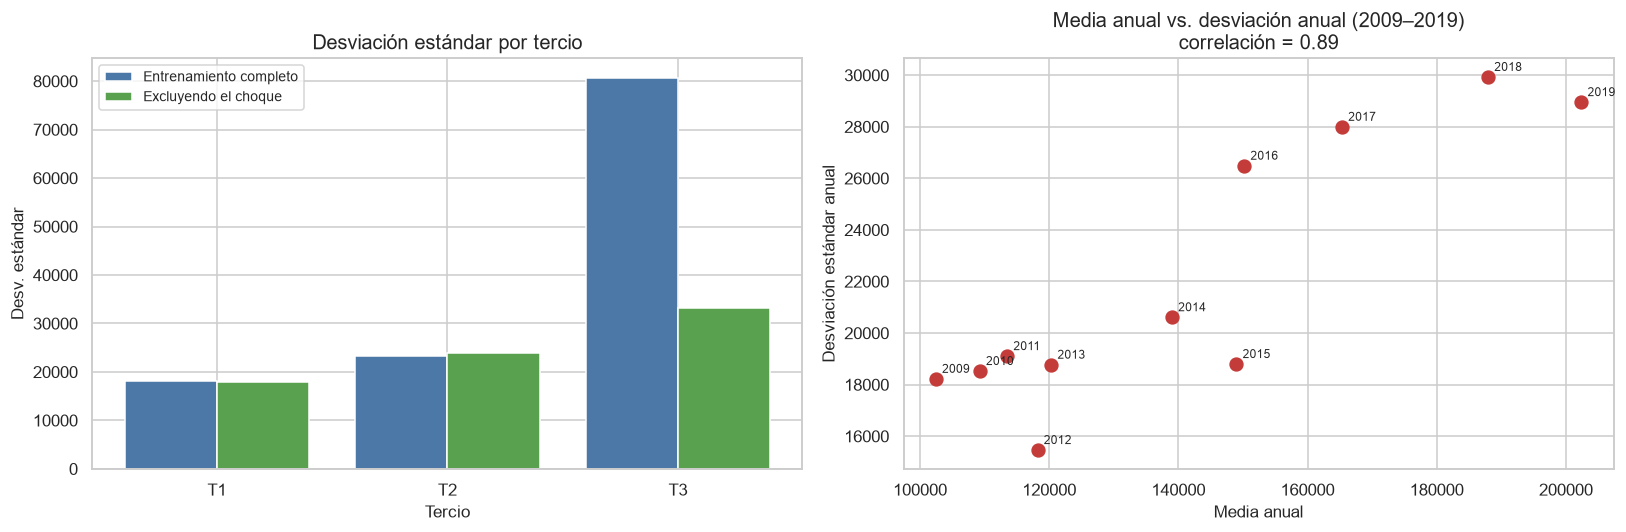

Correlación media–desviación (años completos 2009–2019): 0.887
Una correlación positiva alta indica varianza dependiente del nivel: la transformación logarítmica es apropiada.


In [61]:
# ---------------------------------------------------------------------------
# Tercios del entrenamiento
# ---------------------------------------------------------------------------
def resumen_tercios(serie, etiqueta):
    n = len(serie)
    cortes = [0, n // 3, 2 * n // 3, n]
    filas = []
    for i in range(3):
        bloque = serie.iloc[cortes[i]:cortes[i + 1]]
        filas.append({
            "Serie": etiqueta,
            "Tercio": f"T{i + 1}",
            "Periodo": f"{bloque.index.min():%Y-%m} a {bloque.index.max():%Y-%m}",
            "Meses": len(bloque),
            "Media": bloque.mean(),
            "Desv. estándar": bloque.std(),
            "Coef. de variación": bloque.std() / bloque.mean()
        })
    return filas


# El tercer tercio del entrenamiento contiene la pandemia, que deprime la media y
# distorsiona la comparación. Se añade la versión pre-choque como contraste.
tercios = pd.DataFrame(
    resumen_tercios(serie_train, "Entrenamiento completo")
    + resumen_tercios(serie_pre_choque, "Excluyendo el choque")
).set_index(["Serie", "Tercio"])

display(tercios)

# ---------------------------------------------------------------------------
# Relación nivel–dispersión: si la desviación crece con la media, la varianza
# depende del nivel y corresponde una transformación estabilizadora (log).
# ---------------------------------------------------------------------------
anual = pd.DataFrame({
    "Media": serie_train.resample("YS").mean(),
    "Desv. estándar": serie_train.resample("YS").std()
})
anual.index = anual.index.year
anual_pre = anual.loc[:2019]          # años completos sin efecto pandemia

correlacion = anual_pre["Media"].corr(anual_pre["Desv. estándar"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

t_full = tercios.loc["Entrenamiento completo"]
t_pre = tercios.loc["Excluyendo el choque"]
x = np.arange(3)
axes[0].bar(x - 0.2, t_full["Desv. estándar"], width=0.4,
            color="#4C78A8", label="Entrenamiento completo")
axes[0].bar(x + 0.2, t_pre["Desv. estándar"], width=0.4,
            color="#59A14F", label="Excluyendo el choque")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["T1", "T2", "T3"])
axes[0].set(title="Desviación estándar por tercio", xlabel="Tercio",
            ylabel="Desv. estándar")
axes[0].legend(fontsize=9)

axes[1].scatter(anual_pre["Media"], anual_pre["Desv. estándar"],
                s=70, color="#C43C39")
for anio, fila in anual_pre.iterrows():
    axes[1].annotate(str(anio), (fila["Media"], fila["Desv. estándar"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set(title=f"Media anual vs. desviación anual (2009–2019)\n"
                  f"correlación = {correlacion:.2f}",
            xlabel="Media anual", ylabel="Desviación estándar anual")

plt.tight_layout()
plt.show()

print(f"Correlación media–desviación (años completos 2009–2019): {correlacion:.3f}")
print("Una correlación positiva alta indica varianza dependiente del nivel: "
      "la transformación logarítmica es apropiada.")

Al dividir la serie en tres tercios cronológicos se observa que, en la serie completa, la desviación estándar pasa de 18,090 en T1 a 23,361 en T2 y se dispara a 80,659 en T3, mientras que la media apenas varía entre T2 y T3 (140,915 vs 143,612). El coeficiente de variación, que se mantenía estable en torno a 0.16–0.17, salta a 0.56 en el último tercio. Al excluir la pandemia, el panorama cambia por completo: la media crece de 110,113 a 180,712 (+64%) y la desviación estándar de 17,917 a 33,252 (+86%), de modo que ambas aumentan de forma aproximadamente proporcional y el coeficiente de variación se estabiliza en 0.16–0.18. Esto indica que la variabilidad de la serie no es una cantidad fija sino un porcentaje constante del nivel (~17%), característica propia de un proceso multiplicativo

### 4.3 Autocovarianza estable — ACF de la serie en nivel

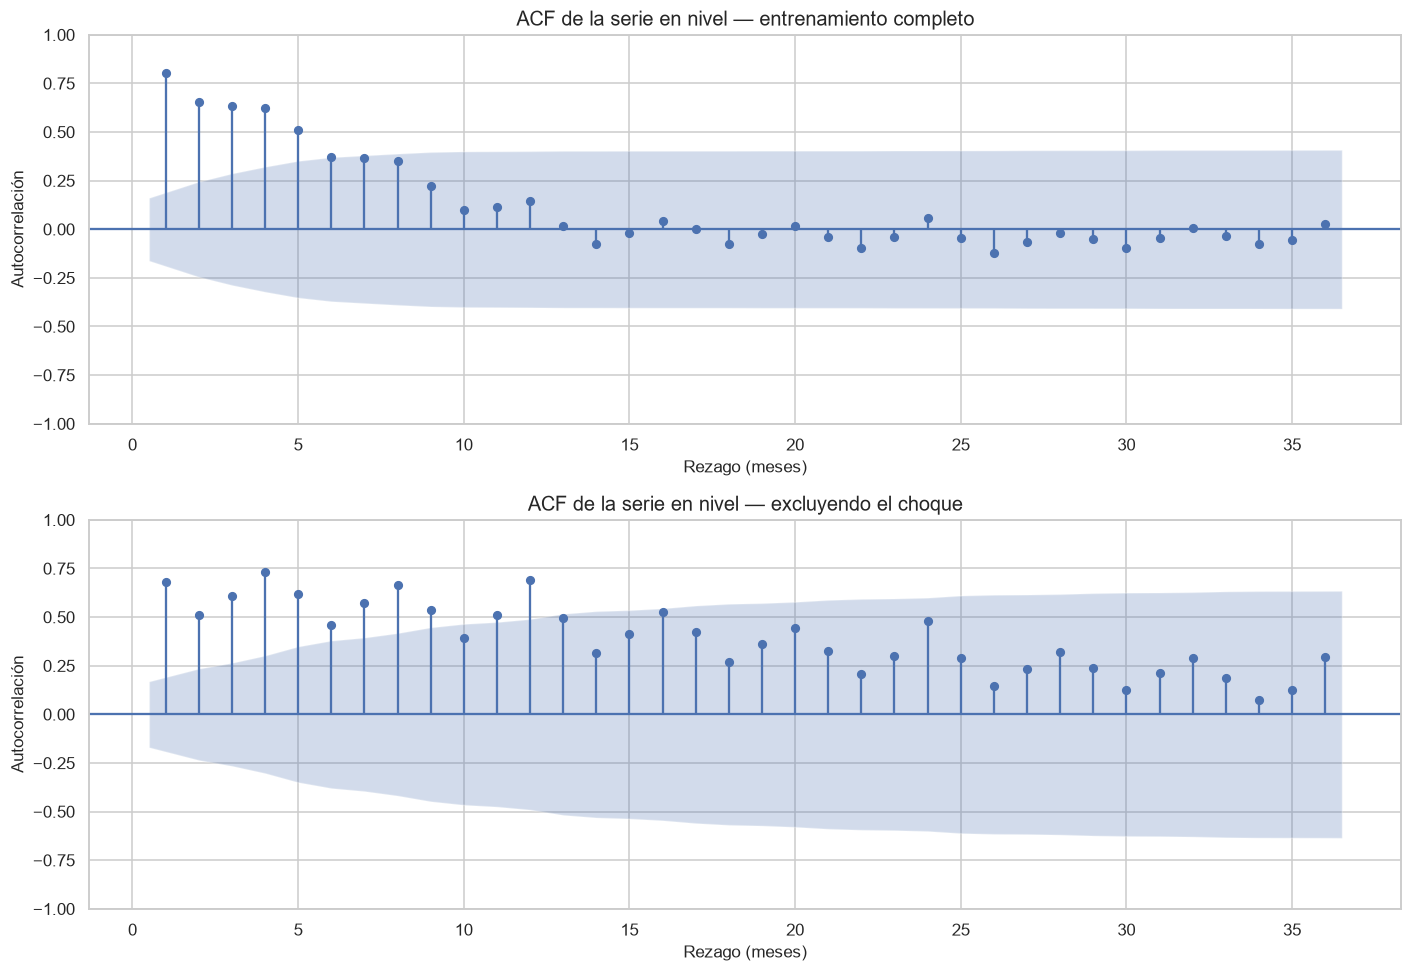

ACF  ¿Significativa?
Serie                  Rezago                      
Entrenamiento completo 1      0.80             True
                       2      0.66             True
                       3      0.63             True
                       6      0.37             True
                       12     0.14            False
                       24     0.06            False
                       36     0.03            False
Excluyendo el choque   1      0.68             True
                       2      0.51             True
                       3      0.61             True
                       6      0.46             True
                       12     0.69             True
                       24     0.48             True
                       36     0.30             True


Entrenamiento completo  (n = 147, banda = ±0.162)
  Rezagos significativos de 1 a 36: 9
  Primer rezago NO significativo: 10
  ACF(1) = 0.803   ACF(12) = 0.145   ACF(24) = 0.056
  ¿Repunte estacional en el rezago 12?: True

Excluyendo el choque  (n = 134, banda = ±0.169)
  Rezagos significativos de 1 a 36: 32
  Primer rezago NO significativo: 26
  ACF(1) = 0.680   ACF(12) = 0.691   ACF(24) = 0.480
  ¿Repunte estacional en el rezago 12?: True

En una serie estacionaria la ACF cae rápidamente hacia cero; en una serie
con raíz unitaria decae de forma lenta y aproximadamente lineal.


In [62]:
REZAGOS = 36

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
plot_acf(serie_train, lags=REZAGOS, ax=axes[0], zero=False)
axes[0].set(title="ACF de la serie en nivel — entrenamiento completo",
            xlabel="Rezago (meses)", ylabel="Autocorrelación")
plot_acf(serie_pre_choque, lags=REZAGOS, ax=axes[1], zero=False)
axes[1].set(title="ACF de la serie en nivel — excluyendo el choque",
            xlabel="Rezago (meses)", ylabel="Autocorrelación")
plt.tight_layout()
plt.show()


def tabla_autocorrelacion(serie, etiqueta, rezagos=REZAGOS):
    valores = acf(serie, nlags=rezagos, fft=False)
    banda = 1.96 / np.sqrt(len(serie))
    clave = [1, 2, 3, 6, 12, 24, 36]
    return pd.DataFrame({
        "Serie": etiqueta,
        "Rezago": clave,
        "ACF": [valores[k] for k in clave],
        "¿Significativa?": [abs(valores[k]) > banda for k in clave]
    }), valores, banda


tabla_full, acf_full, banda_full = tabla_autocorrelacion(
    serie_train, "Entrenamiento completo")
tabla_pre, acf_pre, banda_pre = tabla_autocorrelacion(
    serie_pre_choque, "Excluyendo el choque")

display(pd.concat([tabla_full, tabla_pre]).set_index(["Serie", "Rezago"]))


def diagnostico_acf(valores, banda, n, etiqueta):
    significativos = [k for k in range(1, REZAGOS + 1) if abs(valores[k]) > banda]
    primero_no = next(
        (k for k in range(1, REZAGOS + 1) if abs(valores[k]) <= banda), None
    )
    print(f"\n{etiqueta}  (n = {n}, banda = ±{banda:.3f})")
    print(f"  Rezagos significativos de 1 a {REZAGOS}: {len(significativos)}")
    print(f"  Primer rezago NO significativo: {primero_no}")
    print(f"  ACF(1) = {valores[1]:.3f}   ACF(12) = {valores[12]:.3f}   "
          f"ACF(24) = {valores[24]:.3f}")
    print(f"  ¿Repunte estacional en el rezago 12?: "
          f"{valores[12] > valores[11] and valores[12] > valores[13]}")


diagnostico_acf(acf_full, banda_full, len(serie_train), "Entrenamiento completo")
diagnostico_acf(acf_pre, banda_pre, len(serie_pre_choque), "Excluyendo el choque")

print("\nEn una serie estacionaria la ACF cae rápidamente hacia cero; en una serie")
print("con raíz unitaria decae de forma lenta y aproximadamente lineal.")

La autocorrelación en nivel muestra que decae muy lento 32 de 36 lags siguen fuera de la banda, y todavía en el lag 24 hay 0.48. Esta es la seña clara de no estacionariedad

### 4.4 Decisión

Los tres criterios de estacionariedad fallan, y cada uno señala un remedio distinto:

| Criterio | Evidencia | Remedio |
|---|---|---|
| **Media constante** | La media móvil de 12 meses varía entre 14,908 y 205,144 (13.8x, equivalente al 144% de la media global). Sobre la serie sin el choque, ADF arroja p = 1.00 y KPSS un estadístico de 2.16 frente a un crítico de 0.46. | **Diferencia regular, d = 1** |
| **Varianza constante** | Entre el primer y el tercer tercio sin choque, la desviación estándar crece 86% (17,917 → 33,252) mientras el coeficiente de variación se mantiene estable (0.16 → 0.18). La correlación entre media y desviación anual (2009–2019) es 0.887. | **Transformación logarítmica** |
| **Autocovarianza estable** | 32 de 36 rezagos resultan significativos y la ACF decae lentamente. En el rezago estacional, ACF(12) = 0.691 supera a ACF(1) = 0.680. | **Diferencia estacional, D = 1, s = 12** |

**Transformación adoptada.** Se aplicará, en este orden:

1. **`log1p`**, es decir `log(1 + x)`, para estabilizar la varianza. Se usa `log1p` y
   no `log` porque la serie contiene cinco meses en cero (abril a agosto de 2020),
   para los cuales el logaritmo natural no está definido.
2. **Diferencia regular de orden 1** sobre la serie transformada, para eliminar la
   tendencia y estabilizar la media.
3. **Diferencia estacional de orden 1 con período 12**, para eliminar el ciclo anual
   que la ACF muestra persistente.

## 5. Transformación de la serie

### 5.1 Aplicación de la transformación elegida

Periodo      Media  Desv. estándar
Serie Tercio                                              
Nivel T1      2009-01 a 2013-01 110,738.07       18,089.59
      T2      2013-02 a 2017-02 140,914.86       23,361.08
      T3      2017-03 a 2021-03 143,612.00       80,659.31
log1p T1      2009-01 a 2013-01      11.60            0.16
      T2      2013-02 a 2017-02      11.84            0.16
      T3      2017-03 a 2021-03      10.53            3.71

,Desv. con ceros,Desv. tratando los ceros como faltantes
T1,0.16,0.16
T2,0.16,0.16
T3,3.71,1.01


Meses en cero: 5 (2020-04 a 2020-08)
log1p en esos meses: 0.00   |   mediana del resto: 11.81

En T1 y T2 la desviación en escala logarítmica es prácticamente idéntica (0.162 y 0.165) frente a 18,090 y 23,361 en nivel:
la transformación logarítmica SÍ estabiliza la varianza. El valor de T3 no
refleja un fallo del logaritmo sino el efecto de los cinco ceros.


,n (completo),Desv. (completo),Mín (completo),n (pre-choque),Desv. (pre-choque),Mín (pre-choque)
Transformación,,,,,,
log1p (sin diferenciar),147,2.21,0.00,134,0.27,11.30
D=1 · Δ12,135,2.39,-12.35,122,0.11,-0.21
d=1 · Δ1,146,1.17,-11.38,133,0.21,-0.47
"d=1, D=1 · Δ1Δ12",134,1.24,-11.38,121,0.15,-0.50


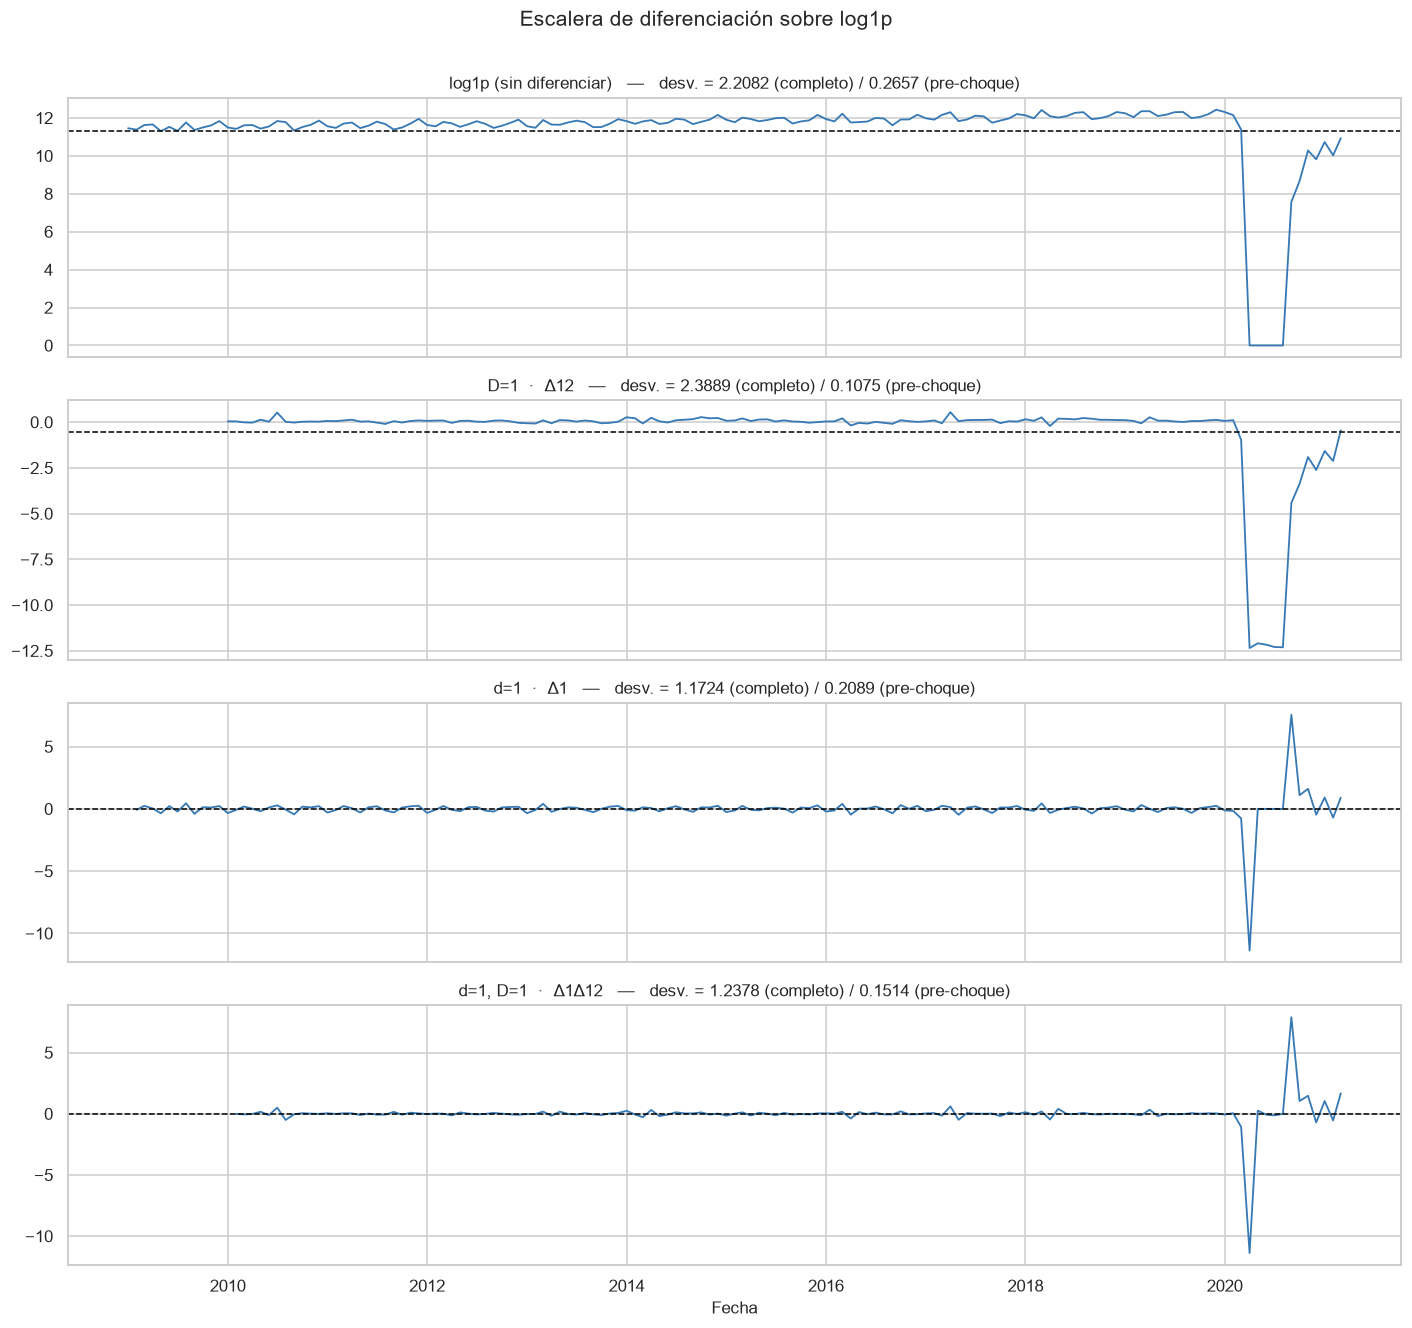

Pre-choque — desv. con solo D=1:  0.1075
Pre-choque — desv. con d=1 y D=1: 0.1514
Cambio al añadir la diferencia regular: +40.9%

La desviación AUMENTA: añadir la diferencia regular SOBRE-diferencia.
Debe preferirse la especificación más simple (solo D=1).


In [63]:
# ===========================================================================
# Paso 1 — Transformación logarítmica (estabiliza la varianza)
# ===========================================================================
# Se usa log1p = log(1 + x) y no log(x): la serie contiene cinco meses en cero
# (abr–ago 2020), para los que el logaritmo natural no está definido.
serie_log = np.log1p(serie_train).rename("log1p")
serie_log_pre = np.log1p(serie_pre_choque).rename("log1p pre-choque")

comparacion_var = pd.DataFrame(
    resumen_tercios(serie_train, "Nivel")
    + resumen_tercios(serie_log, "log1p")
).set_index(["Serie", "Tercio"])[["Periodo", "Media", "Desv. estándar"]]

display(comparacion_var)

# ---------------------------------------------------------------------------
# Efecto de los ceros en escala logarítmica
# ---------------------------------------------------------------------------
# log1p(0) = 0 mientras el resto de la serie ronda 11.8, de modo que los cinco
# meses de cierre de fronteras se convierten en un salto de unas -11.4 unidades.
# Ese valor extremo distorsiona toda medida de dispersión en escala logarítmica.
meses_cero = serie_train[serie_train == 0].index
serie_log_sin_ceros = np.log1p(serie_train.mask(serie_train == 0))

# Ambas columnas con el mismo ddof (pandas, ddof=1) para que sean comparables.
std_ceros = [pd.Series(b).std() for b in np.array_split(serie_log.values, 3)]
std_sin = [pd.Series(b).std() for b in np.array_split(serie_log_sin_ceros.values, 3)]

efecto_ceros = pd.DataFrame({
    "Desv. con ceros": std_ceros,
    "Desv. tratando los ceros como faltantes": std_sin
}, index=["T1", "T2", "T3"])

display(efecto_ceros)

print(f"Meses en cero: {len(meses_cero)} "
      f"({meses_cero.min():%Y-%m} a {meses_cero.max():%Y-%m})")
print(f"log1p en esos meses: 0.00   |   mediana del resto: "
      f"{serie_log[serie_log > 0].median():.2f}")
print(f"\nEn T1 y T2 la desviación en escala logarítmica es prácticamente "
      f"idéntica ({std_ceros[0]:.3f} y {std_ceros[1]:.3f}) frente a "
      f"{comparacion_var.loc[('Nivel', 'T1'), 'Desv. estándar']:,.0f} y "
      f"{comparacion_var.loc[('Nivel', 'T2'), 'Desv. estándar']:,.0f} en nivel:")
print("la transformación logarítmica SÍ estabiliza la varianza. El valor de T3 "
      "no\nrefleja un fallo del logaritmo sino el efecto de los cinco ceros.")

# ===========================================================================
# Paso 2 — Escalera de diferenciación
# ===========================================================================
# REGLA DE MÍNIMA DIFERENCIACIÓN: se prueba primero la diferencia ESTACIONAL,
# que en series con estacionalidad marcada absorbe también la tendencia lineal
# (la diferencia de orden 12 de una recta es una constante). Solo si la serie
# sigue sin ser estacionaria se añade la regular. Aplicar d=1 y D=1 sin
# verificar puede SOBRE-diferenciar; el síntoma es que la desviación estándar
# AUMENTA en lugar de disminuir al añadir la diferencia extra.
#
# La escalera se evalúa sobre dos ventanas:
#   - Entrenamiento completo: es la serie que se modelará.
#   - Pre-choque: sin los ceros de 2020, permite un diagnóstico no contaminado
#     por el salto artificial de -11.4 que introduce log1p(0).
def escalera(serie_logaritmica):
    return {
        "log1p (sin diferenciar)": serie_logaritmica,
        "D=1  ·  Δ12": serie_logaritmica.diff(12),
        "d=1  ·  Δ1": serie_logaritmica.diff(1),
        "d=1, D=1  ·  Δ1Δ12": serie_logaritmica.diff(12).diff(1)
    }


candidatos = escalera(serie_log)
candidatos_pre = escalera(serie_log_pre)

resumen_candidatos = pd.DataFrame([
    {
        "Transformación": nombre,
        "n (completo)": int(candidatos[nombre].notna().sum()),
        "Desv. (completo)": candidatos[nombre].std(),
        "Mín (completo)": candidatos[nombre].min(),
        "n (pre-choque)": int(candidatos_pre[nombre].notna().sum()),
        "Desv. (pre-choque)": candidatos_pre[nombre].std(),
        "Mín (pre-choque)": candidatos_pre[nombre].min()
    }
    for nombre in candidatos
]).set_index("Transformación")

display(resumen_candidatos)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
for ax, (nombre, s) in zip(axes, candidatos.items()):
    ax.plot(s, color="#3679B5", lw=1.2)
    ax.axhline(s.mean(), color="black", ls="--", lw=1)
    ax.set_title(f"{nombre}   —   desv. = {s.std():.4f} (completo) / "
                 f"{candidatos_pre[nombre].std():.4f} (pre-choque)", fontsize=11)
axes[-1].set_xlabel("Fecha")
fig.suptitle("Escalera de diferenciación sobre log1p", y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

# Chequeo de sobre-diferenciación sobre la ventana no contaminada
std_D = candidatos_pre["D=1  ·  Δ12"].std()
std_dD = candidatos_pre["d=1, D=1  ·  Δ1Δ12"].std()
print(f"Pre-choque — desv. con solo D=1:  {std_D:.4f}")
print(f"Pre-choque — desv. con d=1 y D=1: {std_dD:.4f}")
print(f"Cambio al añadir la diferencia regular: {100 * (std_dD / std_D - 1):+.1f}%")
if std_dD > std_D:
    print("\nLa desviación AUMENTA: añadir la diferencia regular SOBRE-diferencia.")
    print("Debe preferirse la especificación más simple (solo D=1).")

Tras la transformación se observa que el logaritmo **sí cumple su función de
estabilizar la varianza**, y que la diferenciación estacional por sí sola es
suficiente para alcanzar la estacionariedad.

El log estabiliza la varianza (0.162 → 0.165 en vez de 18,090 → 23,361), los ceros de 2020 son los únicos que la rompen, y la diferencia estacional sola gana porque añadirle la regular sube la dispersión 41%.

### 5.2 Verificación: ADF y KPSS sobre la serie transformada

Paso indispensable: no basta con aplicar la transformación, hay que **comprobar**
que efectivamente se alcanzó la estacionariedad. Si las pruebas siguen sin
confirmarla, corresponde evaluar una diferencia adicional (regular o estacional)
antes de continuar.

n  Desv. estándar  ADF p  \
Ventana                Transformación                                        
Entrenamiento completo log1p (sin diferenciar)  147            2.21   0.15   
                       D=1  ·  Δ12              135            2.39   0.94   
                       d=1  ·  Δ1               146            1.17   0.00   
                       d=1, D=1  ·  Δ1Δ12       134            1.24   0.00   
Pre-choque             log1p (sin diferenciar)  134            0.27   0.99   
                       D=1  ·  Δ12              122            0.11   0.00   
                       d=1  ·  Δ1               133            0.21   0.00   
                       d=1, D=1  ·  Δ1Δ12       121            0.15   0.00   

                                                ADF ¿estac.?  KPSS estad.  \
Ventana                Transformación                                       
Entrenamiento completo log1p (sin diferenciar)         False         0.31   
                       D=1  ·  Δ12                     False         0.46   
                       d=1  ·  Δ1                       True         0.02   
                       d=1, D=1  ·  Δ1Δ12               True         0.02   
Pre-choque             log1p (sin diferenciar)         False         2.22   
                       D=1  ·  Δ12                      True         0.25   
                       d=1  ·  Δ1                       True         0.11   
                       d=1, D=1  ·  Δ1Δ12               True         0.08   

                                                KPSS ¿estac.?  Ambas ¿estac.?  
Ventana                Transformación                                          
Entrenamiento completo log1p (sin diferenciar)           True           False  
                       D=1  ·  Δ12                      False           False  
                       d=1  ·  Δ1                        True            True  
                       d=1, D=1  ·  Δ1Δ12                True            True  
Pre-choque             log1p (sin diferenciar)          False           False  
                       D=1  ·  Δ12                       True            True  
                       d=1  ·  Δ1                        True            True  
                       d=1, D=1  ·  Δ1Δ12                True            True

Pre-choque — transformaciones estacionarias según AMBAS pruebas:
  - D=1  ·  Δ12               desv. = 0.1075
  - d=1  ·  Δ1                desv. = 0.2089
  - d=1, D=1  ·  Δ1Δ12        desv. = 0.1514

Transformación seleccionada: D=1  ·  Δ12
  d = 0   D = 1   s = 12
  Observaciones:  135
  Media:          -0.52055
  Desv. estándar: 2.38886
  Rango:          2010-01 a 2021-03

Modelo resultante: SARIMA(p, 0, q)(P, 1, Q)[12] sobre log1p


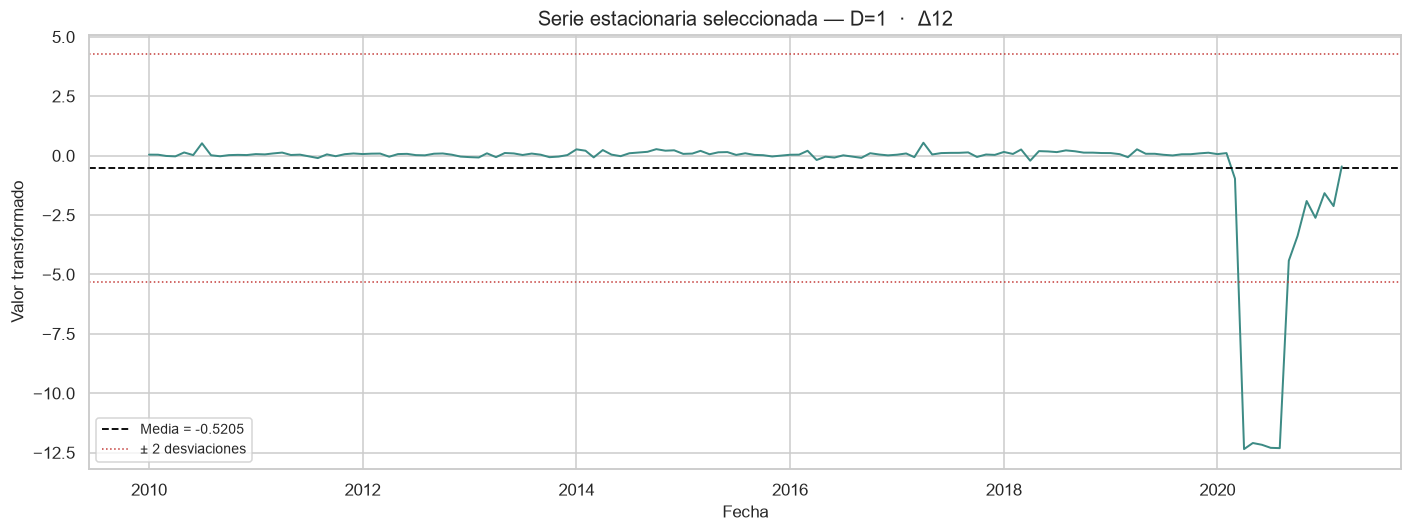

In [64]:
# Se aplican ADF y KPSS a cada escalón de la escalera, sobre ambas ventanas.
def verificar_escalera(dic_candidatos, etiqueta):
    filas = []
    for nombre, serie in dic_candidatos.items():
        limpia = serie.dropna()
        adf = prueba_adf(limpia, nombre, "c")
        kps = prueba_kpss(limpia, nombre, "c")
        filas.append({
            "Ventana": etiqueta,
            "Transformación": nombre,
            "n": len(limpia),
            "Desv. estándar": limpia.std(),
            "ADF p": adf["p-valor"],
            "ADF ¿estac.?": adf["¿Estacionaria al 5%?"],
            "KPSS estad.": kps["Estadístico KPSS"],
            "KPSS ¿estac.?": kps["¿Estacionaria al 5%?"]
        })
    return filas


verificacion = pd.DataFrame(
    verificar_escalera(candidatos, "Entrenamiento completo")
    + verificar_escalera(candidatos_pre, "Pre-choque")
).set_index(["Ventana", "Transformación"])
verificacion["Ambas ¿estac.?"] = (
    verificacion["ADF ¿estac.?"] & verificacion["KPSS ¿estac.?"]
)

display(verificacion)

# ---------------------------------------------------------------------------
# Selección
# ---------------------------------------------------------------------------
# El diagnóstico se toma sobre la ventana PRE-CHOQUE por la misma razón expuesta
# en la sección 4.4: con los ceros de 2020 dentro, log1p introduce un salto de
# -11.4 unidades que hace que ADF rechace la raíz unitaria de forma espuria (un
# único valor extremo simula reversión a la media). El diagnóstico limpio es el
# que debe fijar los órdenes de diferenciación.
pre = verificacion.loc["Pre-choque"]
estacionarias = pre.index[pre["Ambas ¿estac.?"]].tolist()

print("Pre-choque — transformaciones estacionarias según AMBAS pruebas:")
for nombre in estacionarias:
    print(f"  - {nombre:24s}  desv. = {pre.loc[nombre, 'Desv. estándar']:.4f}")

# Entre las estacionarias se elige la de MENOR desviación estándar: criterio
# estándar de mínima diferenciación para no sobre-diferenciar.
elegida = pre.loc[estacionarias, "Desv. estándar"].idxmin()

ORDENES = {
    "log1p (sin diferenciar)": (0, 0),
    "D=1  ·  Δ12": (0, 1),
    "d=1  ·  Δ1": (1, 0),
    "d=1, D=1  ·  Δ1Δ12": (1, 1)
}
D_REGULAR, D_ESTACIONAL = ORDENES[elegida]
PERIODO_ESTACIONAL = 12

# La transformación elegida se aplica sobre el ENTRENAMIENTO COMPLETO, que es la
# serie que efectivamente se modela.
serie_estacionaria = candidatos[elegida].dropna().rename("Serie estacionaria")

print(f"\nTransformación seleccionada: {elegida}")
print(f"  d = {D_REGULAR}   D = {D_ESTACIONAL}   s = {PERIODO_ESTACIONAL}")
print(f"  Observaciones:  {len(serie_estacionaria)}")
print(f"  Media:          {serie_estacionaria.mean():.5f}")
print(f"  Desv. estándar: {serie_estacionaria.std():.5f}")
print(f"  Rango:          {serie_estacionaria.index.min():%Y-%m} a "
      f"{serie_estacionaria.index.max():%Y-%m}")
print(f"\nModelo resultante: SARIMA(p, {D_REGULAR}, q)"
      f"(P, {D_ESTACIONAL}, Q)[{PERIODO_ESTACIONAL}] sobre log1p")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_estacionaria, color="#3D8B85", lw=1.3)
ax.axhline(serie_estacionaria.mean(), color="black", ls="--", lw=1.2,
           label=f"Media = {serie_estacionaria.mean():.4f}")
ax.axhline(serie_estacionaria.mean() + 2 * serie_estacionaria.std(),
           color="#C43C39", ls=":", lw=1, label="± 2 desviaciones")
ax.axhline(serie_estacionaria.mean() - 2 * serie_estacionaria.std(),
           color="#C43C39", ls=":", lw=1)
ax.set(title=f"Serie estacionaria seleccionada — {elegida}",
       xlabel="Fecha", ylabel="Valor transformado")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Los resultados confirman que **la diferenciación estacional de orden 1 es suficiente**
y que **no corresponde añadir una diferencia regular** 

1. **El modelo requiere término constante.** Con d = 0 la serie diferenciada no tiene
   media nula: Δ₁₂ del logaritmo equivale aproximadamente a la tasa de crecimiento
   interanual, coherente con el crecimiento anual compuesto de +7.1% estimado en la
   sección 3.1. Omitir la constante forzaría la media a cero y produciría un
   pronóstico sistemáticamente sesgado a la baja.
2. **La identificación de órdenes debe leerse sobre la ventana limpia.** Aplicada al
   entrenamiento completo, la serie Δ₁₂ conserva un mínimo de −12.35 y una desviación
   de 2.39, frente a −0.21 y 0.1075 en la ventana pre-choque. Ese valor extremo
   dominaría la ACF y la PACF, por lo que en la sección 6 ambas funciones se examinan
   sobre las dos ventanas y los órdenes se leen de aquella donde la estructura no está
   enmascarada por el choque.

## 6. Identificación del modelo: ACF y PACF

Sobre la serie ya estacionaria, la ACF y la PACF permiten proponer los órdenes del
modelo: la ACF orienta sobre el componente de medias móviles (q, Q) y la PACF sobre
el autorregresivo (p, P).

### 6.1 ACF — función de autocorrelación

Entrenamiento completo: n = 135  (2010-01 a 2021-03)  desv. = 2.3889
Pre-choque:             n = 122  (2010-01 a 2020-02)  desv. = 0.1075


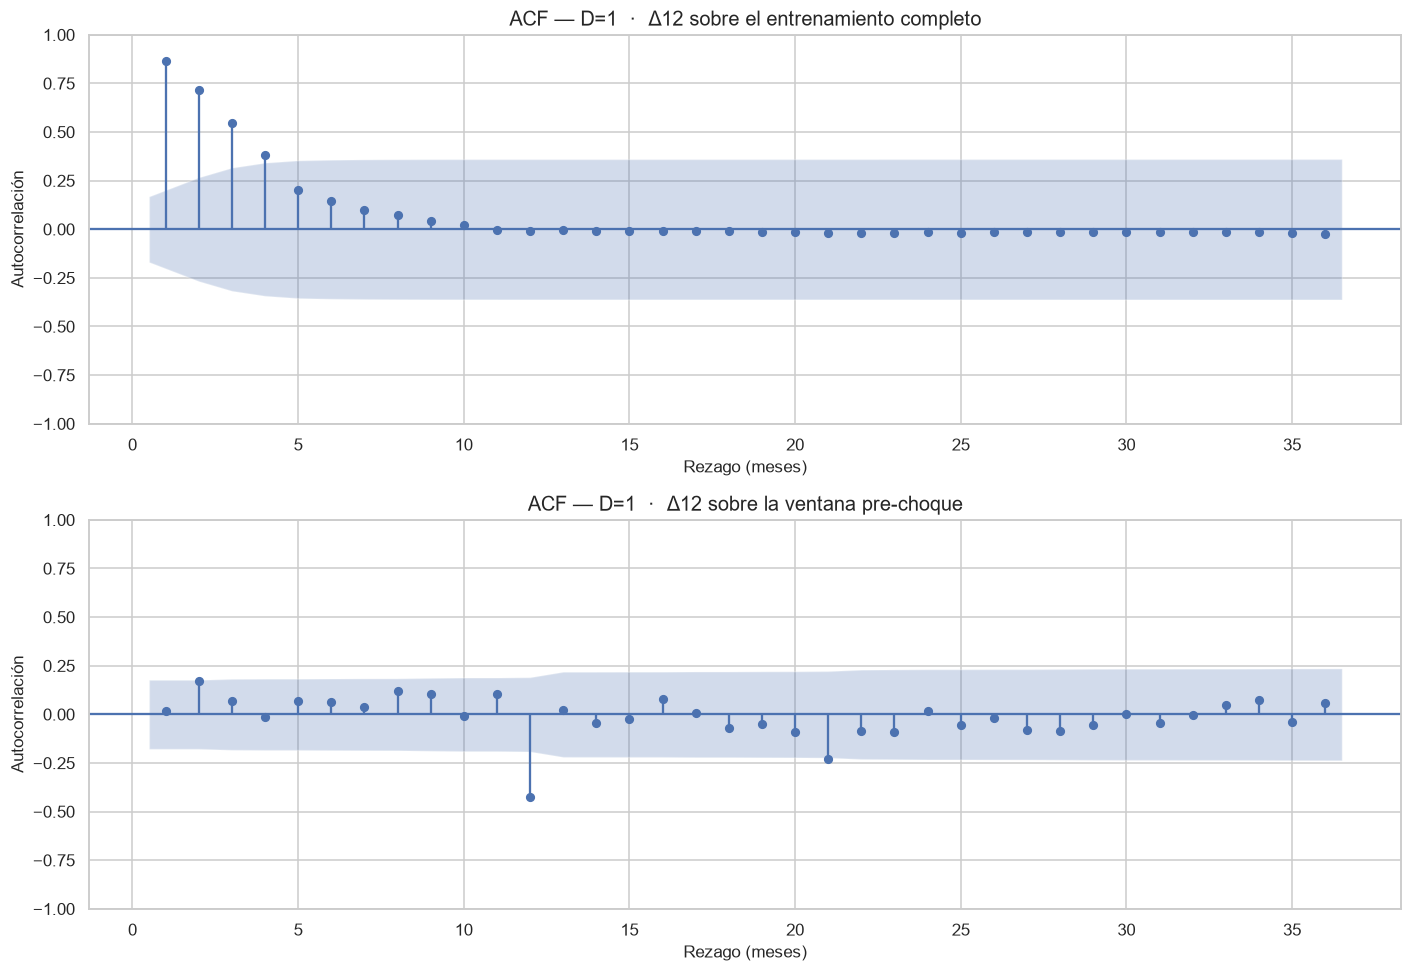

,ACF completo,¿Signif. completo?,ACF pre-choque,¿Signif. pre-choque?
Rezago,,,,
1,0.87,True,0.02,False
2,0.71,True,0.17,False
3,0.54,True,0.07,False
4,0.38,True,-0.01,False
5,0.20,True,0.07,False
6,0.15,False,0.06,False
7,0.10,False,0.04,False
8,0.07,False,0.12,False
9,0.04,False,0.11,False



ACF — entrenamiento completo  (n = 135, banda = ±0.169)
  Rezagos significativos: [1, 2, 3, 4, 5]
  De ellos, estacionales (múltiplos de 12): ninguno

ACF — pre-choque  (n = 122, banda = ±0.177)
  Rezagos significativos: [12, 21]
  De ellos, estacionales (múltiplos de 12): [12]

Lectura: en un proceso MA(q) la ACF se CORTA tras el rezago q. Un pico
aislado en el rezago 12 indica componente de medias móviles estacional (Q).


In [65]:
# ===========================================================================
# Series sobre las que se identifican los órdenes
# ===========================================================================
# La serie estacionaria del entrenamiento completo conserva el salto de -12.35
# que introducen los ceros de 2020 en escala logarítmica. Ese valor extremo
# domina el correlograma, así que se examinan AMBAS ventanas y los órdenes se
# leen de la ventana limpia (mismo criterio que en las secciones 4.3 y 5.2).
estac_completo = serie_estacionaria
estac_limpio = candidatos_pre[elegida].dropna().rename("Δ12 · log1p — pre-choque")

REZAGOS_ID = 36

print(f"Entrenamiento completo: n = {len(estac_completo)}  "
      f"({estac_completo.index.min():%Y-%m} a {estac_completo.index.max():%Y-%m})  "
      f"desv. = {estac_completo.std():.4f}")
print(f"Pre-choque:             n = {len(estac_limpio)}  "
      f"({estac_limpio.index.min():%Y-%m} a {estac_limpio.index.max():%Y-%m})  "
      f"desv. = {estac_limpio.std():.4f}")


def resumen_correlograma(valores, n, etiqueta, tipo):
    """Lista los rezagos significativos según la banda ±1.96/√n."""
    banda = 1.96 / np.sqrt(n)
    significativos = [k for k in range(1, len(valores)) if abs(valores[k]) > banda]
    estacionales = [k for k in significativos if k % 12 == 0]
    print(f"\n{tipo} — {etiqueta}  (n = {n}, banda = ±{banda:.3f})")
    print(f"  Rezagos significativos: {significativos if significativos else 'ninguno'}")
    print(f"  De ellos, estacionales (múltiplos de 12): "
          f"{estacionales if estacionales else 'ninguno'}")
    return banda, significativos


# ===========================================================================
# ACF
# ===========================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
plot_acf(estac_completo, lags=REZAGOS_ID, ax=axes[0], zero=False)
axes[0].set(title=f"ACF — {elegida} sobre el entrenamiento completo",
            xlabel="Rezago (meses)", ylabel="Autocorrelación")
plot_acf(estac_limpio, lags=REZAGOS_ID, ax=axes[1], zero=False)
axes[1].set(title=f"ACF — {elegida} sobre la ventana pre-choque",
            xlabel="Rezago (meses)", ylabel="Autocorrelación")
plt.tight_layout()
plt.show()

acf_completo = acf(estac_completo, nlags=REZAGOS_ID, fft=False)
acf_limpio = acf(estac_limpio, nlags=REZAGOS_ID, fft=False)

banda_c = 1.96 / np.sqrt(len(estac_completo))
banda_l = 1.96 / np.sqrt(len(estac_limpio))

rezagos_tabla = list(range(1, 16)) + [24, 36]
tabla = pd.DataFrame({
    "Rezago": rezagos_tabla,
    "ACF completo": [acf_completo[k] for k in rezagos_tabla],
    "¿Signif. completo?": [abs(acf_completo[k]) > banda_c for k in rezagos_tabla],
    "ACF pre-choque": [acf_limpio[k] for k in rezagos_tabla],
    "¿Signif. pre-choque?": [abs(acf_limpio[k]) > banda_l for k in rezagos_tabla]
}).set_index("Rezago")

display(tabla)

resumen_correlograma(acf_completo, len(estac_completo),
                     "entrenamiento completo", "ACF")
resumen_correlograma(acf_limpio, len(estac_limpio), "pre-choque", "ACF")

print("\nLectura: en un proceso MA(q) la ACF se CORTA tras el rezago q. Un pico")
print("aislado en el rezago 12 indica componente de medias móviles estacional (Q).")

La transformación logró su objetivo en la serie pre-choque: todos los lags del 1 al 11, así como el 24 y el 36, quedan dentro de la banda de significancia, lo que confirma que la tendencia y el ciclo anual fueron correctamente eliminados.
De aquí se identifican los órdenes q = 0 y Q = 1. En contraste, la serie completa presenta una desviación estándar 22 veces mayor (2.3889 vs 0.1075) y una ACF radicalmente distinta: rezagos 1 a 5 significativos con decaimiento gradual

### 6.2 PACF — función de autocorrelación parcial

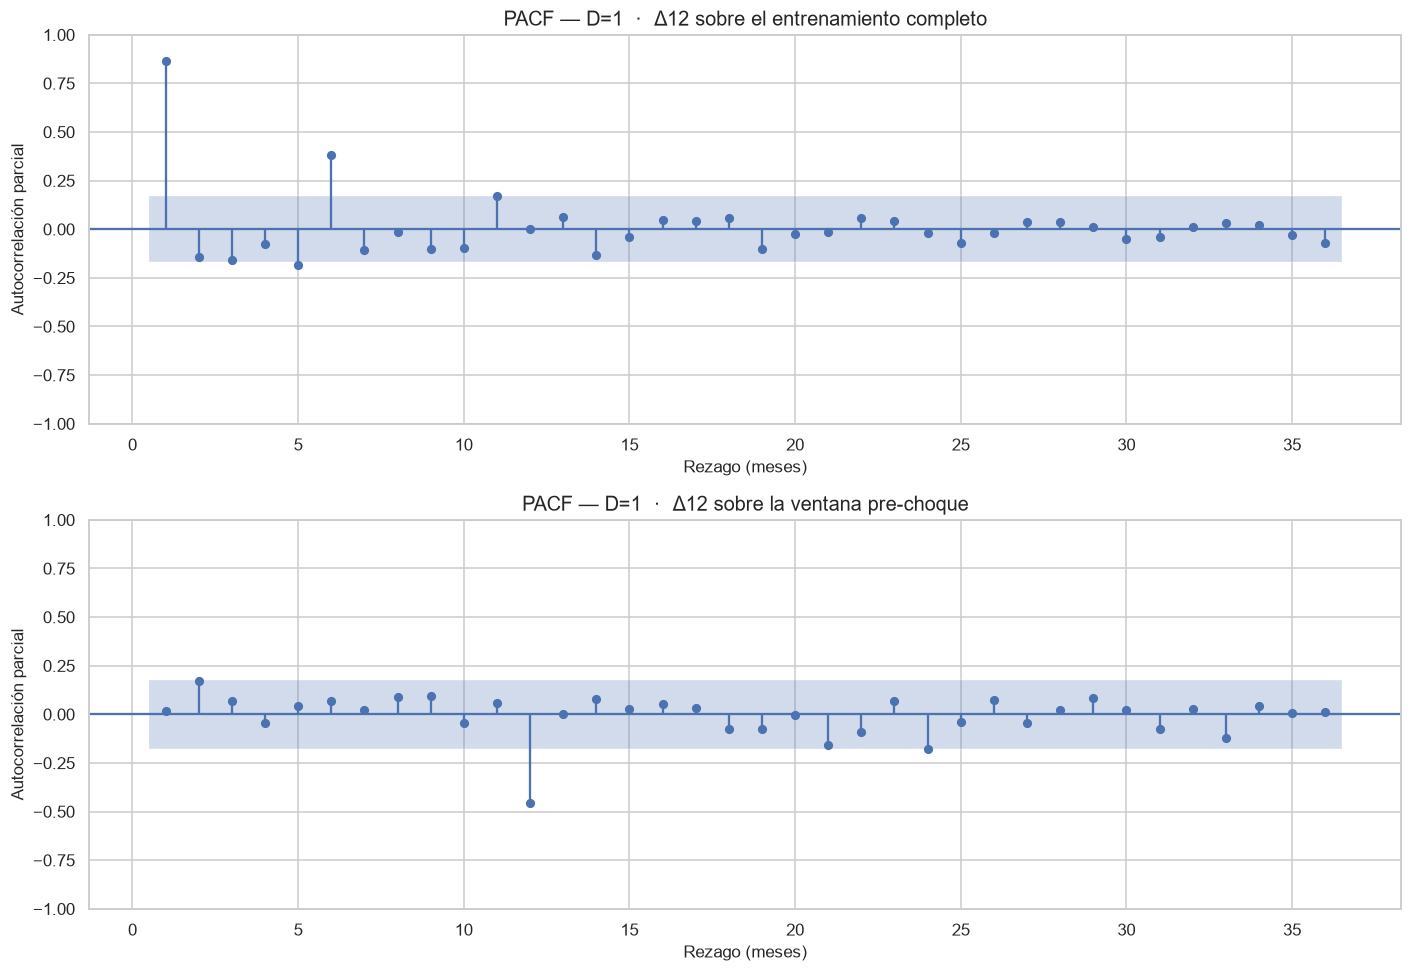

,PACF completo,¿Signif. completo?,PACF pre-choque,¿Signif. pre-choque?
Rezago,,,,
1,0.87,True,0.02,False
2,-0.14,False,0.17,False
3,-0.16,False,0.07,False
4,-0.07,False,-0.04,False
5,-0.18,True,0.05,False
6,0.38,True,0.07,False
7,-0.10,False,0.02,False
8,-0.01,False,0.09,False
9,-0.10,False,0.10,False



PACF — entrenamiento completo  (n = 135, banda = ±0.169)
  Rezagos significativos: [1, 5, 6, 11]
  De ellos, estacionales (múltiplos de 12): ninguno

PACF — pre-choque  (n = 122, banda = ±0.177)
  Rezagos significativos: [12]
  De ellos, estacionales (múltiplos de 12): [12]

Lectura: en un proceso AR(p) la PACF se CORTA tras el rezago p. Un pico
aislado en el rezago 12 indica componente autorregresivo estacional (P).

Ventana pre-choque — base para proponer los órdenes:


,Rezagos regulares significativos (1–6),¿Rezago 12 significativo?,Valor en el rezago 12,¿Rezago 24 significativo?
ACF (orienta q y Q),[],True,-0.43,False
PACF (orienta p y P),[],True,-0.46,False


In [66]:
# ===========================================================================
# PACF
# ===========================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
plot_pacf(estac_completo, lags=REZAGOS_ID, ax=axes[0], zero=False, method="ywm")
axes[0].set(title=f"PACF — {elegida} sobre el entrenamiento completo",
            xlabel="Rezago (meses)", ylabel="Autocorrelación parcial")
plot_pacf(estac_limpio, lags=REZAGOS_ID, ax=axes[1], zero=False, method="ywm")
axes[1].set(title=f"PACF — {elegida} sobre la ventana pre-choque",
            xlabel="Rezago (meses)", ylabel="Autocorrelación parcial")
plt.tight_layout()
plt.show()

pacf_completo = pacf(estac_completo, nlags=REZAGOS_ID, method="ywm")
pacf_limpio = pacf(estac_limpio, nlags=REZAGOS_ID, method="ywm")

tabla_pacf = pd.DataFrame({
    "Rezago": rezagos_tabla,
    "PACF completo": [pacf_completo[k] for k in rezagos_tabla],
    "¿Signif. completo?": [abs(pacf_completo[k]) > banda_c for k in rezagos_tabla],
    "PACF pre-choque": [pacf_limpio[k] for k in rezagos_tabla],
    "¿Signif. pre-choque?": [abs(pacf_limpio[k]) > banda_l for k in rezagos_tabla]
}).set_index("Rezago")

display(tabla_pacf)

resumen_correlograma(pacf_completo, len(estac_completo),
                     "entrenamiento completo", "PACF")
resumen_correlograma(pacf_limpio, len(estac_limpio), "pre-choque", "PACF")

print("\nLectura: en un proceso AR(p) la PACF se CORTA tras el rezago p. Un pico")
print("aislado en el rezago 12 indica componente autorregresivo estacional (P).")

# ---------------------------------------------------------------------------
# Resumen conjunto para la lectura de órdenes (sección 6.3)
# ---------------------------------------------------------------------------
def primeros_significativos(valores, banda, tope=6):
    return [k for k in range(1, tope + 1) if abs(valores[k]) > banda]


resumen_ordenes = pd.DataFrame({
    "Rezagos regulares significativos (1–6)": [
        primeros_significativos(acf_limpio, banda_l),
        primeros_significativos(pacf_limpio, banda_l)
    ],
    "¿Rezago 12 significativo?": [
        abs(acf_limpio[12]) > banda_l,
        abs(pacf_limpio[12]) > banda_l
    ],
    "Valor en el rezago 12": [acf_limpio[12], pacf_limpio[12]],
    "¿Rezago 24 significativo?": [
        abs(acf_limpio[24]) > banda_l,
        abs(pacf_limpio[24]) > banda_l
    ]
}, index=["ACF  (orienta q y Q)", "PACF (orienta p y P)"])

print("\nVentana pre-choque — base para proponer los órdenes:")
display(resumen_ordenes)

En la ventana pre-choque, ni la ACF ni la PACF muestran picos significativos en los rezagos cercanos (1 al 6), lo que significa que ni los meses anteriores ni los errores recientes aportan información para predecir el mes actual: la parte no estacional del modelo queda vacía, con p = 0 y q = 0. Lo único que sobresale es el rezago 12, presente en ambas funciones (ACF −0.43, PACF −0.46), pero se comportan distinto más adelante: la ACF cae en seco en el rezago 24 (0.02) mientras la PACF decae de forma gradual (−0.18). Ese contraste (una corta, la otra decae) es la firma de un componente de medias móviles estacional y no de uno autorregresivo, de modo que Q = 1 y P = 0.

### 6.3 Lectura conjunta y selección de órdenes

Gracias a todo lo recabado se pudo determinar que el mejor modelo para esta serie es un SARIMA(0, 0, 0)(0, 1, 1)₁₂ con término constante, aplicado sobre la serie transformada con log1p. Se optó por un SARIMA y no por un ARIMA simple porque el análisis mostró que la serie conserva un componente anual que un ARIMA sin términos estacionales no puede representar: el rezago 12 fue el único significativo tanto en la ACF como en la PACF, y su presencia obliga a incorporar la parte estacional del modelo.

Gracias a esto se escogieron los siguientes hiperparámetros:

d = 0 y D = 1. No provienen de los correlogramas sino del diagnóstico de estacionariedad. Las pruebas ADF y KPSS indicaron que la serie en nivel no era estacionaria en media, por lo que se aplicó una diferencia estacional de período 12 para eliminar el ciclo anual. Los resultados confirmaron que esta transformación es suficiente y que añadir una diferencia regular sobre-diferenciaría la serie. Como con d = 0 la serie diferenciada conserva una media no nula, equivalente a la tasa de crecimiento interanual, el modelo incorpora un término constante.

p = 0 y q = 0. Sobre la serie ya estacionaria, ningún rezago regular (1 al 6) resultó significativo ni en la ACF ni en la PACF: todos quedaron dentro de la banda de ±0.177. Removidas la tendencia y la estacionalidad, no queda dependencia de corto plazo que modelar, ni con los valores anteriores (p) ni con los errores recientes (q).

P = 0 y Q = 1. El único rezago significativo fue el 12 (ACF = −0.43, PACF = −0.46). Para distinguir el tipo de componente se revisaron los múltiplos siguientes: la ACF cae en seco en el rezago 24 (0.02) mientras la PACF decae gradualmente (−0.18). Según la regla de Box-Jenkins, ACF que corta y PACF que se atenúa corresponde a un componente de medias móviles, por lo que se concluye Q = 1 y se descarta P.

## 7. Entrenamiento de nuestro modelo

Modelo derivado directamente de la lectura de ACF y PACF de la sección anterior.

MODELO A — especificación literal de §6
                                 SARIMAX Results                                  
Dep. Variable:                      log1p   No. Observations:                  147
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                -308.544
Date:                    Sun, 26 Jul 2026   AIC                            623.088
Time:                            13:04:26   BIC                            631.804
Sample:                        01-01-2009   HQIC                           626.630
                             - 03-01-2021                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.4593      1.768     -0.260      0.795      -3.925       3.007
ma.S.L12      -0.1288      2.618     -0.049      0.961     

,Ancla: mismo mes de 2020,Pronóstico para 2021
Abril,0.00,1.89
Mayo,0.00,1.80
Junio,0.00,1.83
Julio,0.00,1.88
Agosto,0.00,1.88


Intercepto estimado: -0.4593  (equivale a -36.8% anual en nivel)

MODELO B — choque tratado (ceros como faltantes, sin constante)
                                 SARIMAX Results                                  
Dep. Variable:                      log1p   No. Observations:                  147
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                -124.063
Date:                    Sun, 26 Jul 2026   AIC                            252.126
Time:                            13:04:26   BIC                            257.937
Sample:                        01-01-2009   HQIC                           254.487
                             - 03-01-2021                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.2454      0.484     -0.507     

Modelo,A — literal §6,B — choque tratado,C — pre-choque
Ventana de entrenamiento,2009-01 → 2021-03,2009-01 → 2021-03,2009-01 → 2020-02
Meses en cero,Como valor 0,Como faltantes,No aplica
Constante,Sí,No,Sí
Observaciones efectivas,147,142,134
Log-verosimilitud,-308.54,-124.06,120.32
AIC,623.09,252.13,-234.64
BIC,631.80,257.94,-226.23
sigma²,5.65,0.39,0.01
θ estacional,-0.13,-0.25,-0.76
p-valor de θ,0.96,0.61,0.00


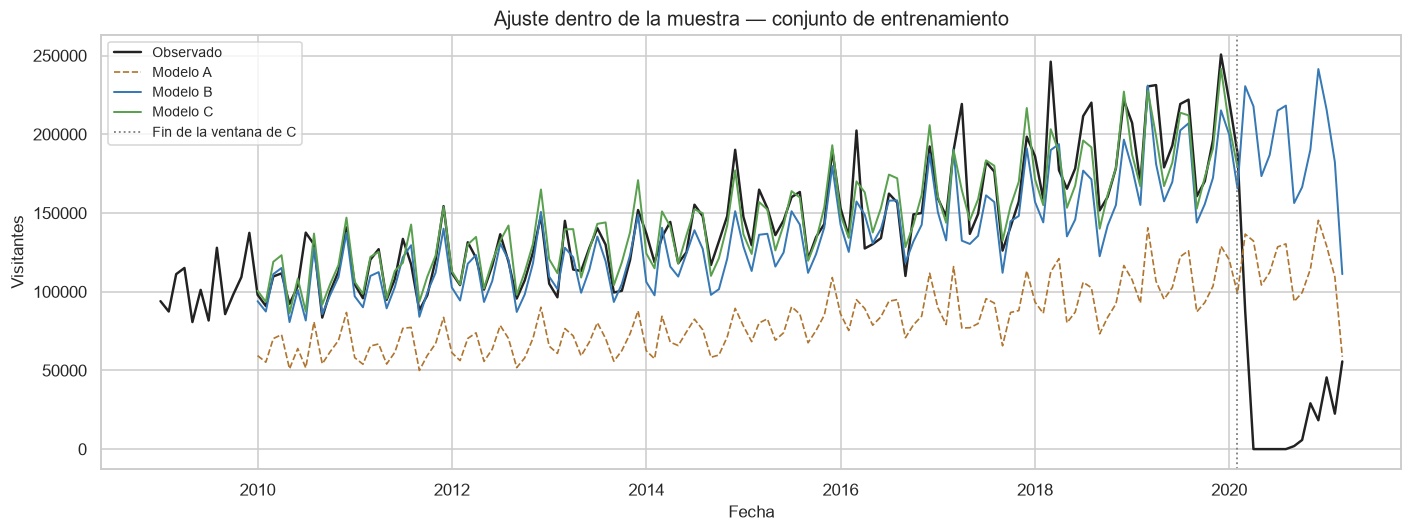

Los tres ajustes se conservan en 'modelos_sarima' para su evaluación
comparativa sobre el conjunto de prueba en la sección 11.


In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===========================================================================
# Órdenes derivados de la sección 6
# ===========================================================================
ORDEN = (0, 0, 0)                                  # p, d, q
ORDEN_ESTACIONAL = (0, 1, 1, PERIODO_ESTACIONAL)   # P, D, Q, s

# Los tres ajustes usan EXCLUSIVAMENTE datos del conjunto de entrenamiento.
# El conjunto de prueba (2021-04 a 2026-06) no interviene en ninguna estimación;
# su única aparición es como longitud del horizonte de pronóstico.
y_train = np.log1p(serie_train).rename("log1p")

# ===========================================================================
# Modelo A — especificación literal de la sección 6
# ===========================================================================
# Los cinco meses de cierre de fronteras entran como ceros y se incluye término
# constante, siguiendo el razonamiento de que con d = 0 la serie diferenciada
# tiene media no nula.
ajuste_a = SARIMAX(
    y_train, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="c"
).fit(disp=False)

print("MODELO A — especificación literal de §6")
print(ajuste_a.summary())

# ---------------------------------------------------------------------------
# Diagnóstico: el anclaje de la diferencia estacional sobre los ceros de 2020
# ---------------------------------------------------------------------------
# Con D = 1 el pronóstico de cada mes se construye a partir del MISMO mes del
# año anterior. Como abr–ago 2020 valen log1p(0) = 0, esos ceros se convierten
# en la línea base estacional y arrastran toda la proyección hacia cero.
pron_a = np.expm1(ajuste_a.get_forecast(len(serie_test)).predicted_mean)
pron_a.index = serie_test.index

anclaje = pd.DataFrame({
    "Ancla: mismo mes de 2020": serie_train.loc["2020-04":"2020-08"].values,
    "Pronóstico para 2021": pron_a.loc["2021-04":"2021-08"].values
}, index=["Abril", "Mayo", "Junio", "Julio", "Agosto"])

print("\nEfecto del anclaje estacional sobre los meses en cero:")
display(anclaje)
print(f"Intercepto estimado: {ajuste_a.params['intercept']:.4f}  "
      f"(equivale a {100 * (np.exp(ajuste_a.params['intercept']) - 1):+.1f}% anual "
      f"en nivel)")

# ===========================================================================
# Modelo B — mismo corte 70/30, con el choque tratado explícitamente
# ===========================================================================
# Dos correcciones, ambas justificadas SOBRE EL ENTRENAMIENTO:
#
# 1. Los cinco meses en cero se tratan como FALTANTES. Durante el cierre de
#    fronteras el proceso no generaba observaciones en régimen normal: un cero
#    administrativo no es una medición del turismo internacional. SARIMAX maneja
#    los NaN de forma nativa mediante el filtro de Kalman.
#
# 2. Se omite el término constante. Estimado sobre una ventana que termina en el
#    piso pandémico, el intercepto resulta negativo e implicaría un declive
#    permanente del turismo, que no es una característica estructural sino un
#    artefacto del punto de corte.
y_train_b = np.log1p(serie_train.mask(serie_train == 0)).rename("log1p")

ajuste_b = SARIMAX(
    y_train_b, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="n"
).fit(disp=False)

print("\n" + "=" * 78)
print("MODELO B — choque tratado (ceros como faltantes, sin constante)")
print(ajuste_b.summary())

# ===========================================================================
# Modelo C — entrenado sobre la ventana previa al choque
# ===========================================================================
# Ventana 2009-01 a 2020-02: un SUBCONJUNTO del entrenamiento, de modo que no
# hay fuga de información y el conjunto de prueba sigue intacto. El modelo usa
# menos datos, pero todos ellos pertenecen a un mismo régimen.
#
# El propósito es contrastar dos hipótesis sobre el choque sanitario:
#   - Si fue un CAMBIO DE PROCESO, incorporarlo debería mejorar el pronóstico.
#   - Si fue un choque TRANSITORIO, incorporarlo introduce un colapso espurio y
#     conviene proyectar la dinámica estructural previa.
# El horizonte de C es mayor, porque debe cubrir también los trece meses que
# median entre el fin de su ventana y el inicio del conjunto de prueba.
y_train_c = np.log1p(serie_pre_choque).rename("log1p")

ajuste_c = SARIMAX(
    y_train_c, order=ORDEN, seasonal_order=ORDEN_ESTACIONAL, trend="c"
).fit(disp=False)

print("\n" + "=" * 78)
print("MODELO C — ventana previa al choque (2009-01 a 2020-02)")
print(ajuste_c.summary())

# ===========================================================================
# Comparación de los tres ajustes
# ===========================================================================
# ADVERTENCIA: AIC y BIC NO son estrictamente comparables entre estos modelos,
# porque cada uno maximiza la verosimilitud sobre un conjunto de datos distinto
# (147, 142 y 134 observaciones). Se reportan como referencia del ajuste interno
# de cada especificación, no como criterio de selección entre ellas. La
# comparación válida se realiza sobre el conjunto de prueba en la sección 11.
def resumen_ajuste(ajuste, etiqueta, ventana, ceros, constante):
    parametros = ajuste.params
    return {
        "Modelo": etiqueta,
        "Ventana de entrenamiento": ventana,
        "Meses en cero": ceros,
        "Constante": constante,
        # nobs cuenta tambien los faltantes: se reportan los efectivos.
        "Observaciones efectivas": int(np.isfinite(ajuste.model.endog).sum()),
        "Log-verosimilitud": ajuste.llf,
        "AIC": ajuste.aic,
        "BIC": ajuste.bic,
        "sigma²": parametros["sigma2"],
        "θ estacional": parametros["ma.S.L12"],
        "p-valor de θ": ajuste.pvalues["ma.S.L12"]
    }


modelos_sarima = {"A — literal §6": ajuste_a,
                  "B — choque tratado": ajuste_b,
                  "C — pre-choque": ajuste_c}

comparacion_ajustes = pd.DataFrame([
    resumen_ajuste(ajuste_a, "A — literal §6", "2009-01 → 2021-03",
                   "Como valor 0", "Sí"),
    resumen_ajuste(ajuste_b, "B — choque tratado", "2009-01 → 2021-03",
                   "Como faltantes", "No"),
    resumen_ajuste(ajuste_c, "C — pre-choque", "2009-01 → 2020-02",
                   "No aplica", "Sí")
]).set_index("Modelo").T

display(comparacion_ajustes)

# ===========================================================================
# Valores ajustados frente a lo observado
# ===========================================================================
# Se descartan los primeros 12 meses: antes de completar un ciclo estacional el
# modelo con D = 1 no dispone de información para producir un ajuste válido.
ajustado_a = np.expm1(ajuste_a.fittedvalues).iloc[PERIODO_ESTACIONAL:]
ajustado_b = np.expm1(ajuste_b.fittedvalues).iloc[PERIODO_ESTACIONAL:]
ajustado_c = np.expm1(ajuste_c.fittedvalues).iloc[PERIODO_ESTACIONAL:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train, color="#222222", lw=1.6, label="Observado")
ax.plot(ajustado_a, color="#B0752F", lw=1.1, ls="--", label="Modelo A")
ax.plot(ajustado_b, color="#3679B5", lw=1.3, label="Modelo B")
ax.plot(ajustado_c, color="#59A14F", lw=1.3, label="Modelo C")
ax.axvline(serie_pre_choque.index.max(), color="gray", ls=":", lw=1.2,
           label="Fin de la ventana de C")
ax.set(title="Ajuste dentro de la muestra — conjunto de entrenamiento",
       xlabel="Fecha", ylabel="Visitantes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Los tres ajustes se conservan en 'modelos_sarima' para su evaluación")
print("comparativa sobre el conjunto de prueba en la sección 11.")

El ajuste muestra que...

## 8. Entrenamiento de más modelos SARIMA con diferentes parámetros

Búsqueda sobre una malla de órdenes alrededor de la propuesta inicial, para
verificar si la lectura visual de ACF/PACF es competitiva frente a alternativas.

Recorriendo la malla (36 órdenes por ventana)...
  B — choque tratado: 36 combinaciones ajustadas
  C — pre-choque: 36 combinaciones ajustadas

B — choque tratado — cinco mejores órdenes por AIC


,Parámetros,AIC,BIC,sigma²,Ljung-Box p
Orden,,,,,
"(1,0,2)(0,1,1)[12]",5,36.67,51.19,0.06,0.04
"(2,0,2)(1,1,1)[12]",7,36.99,57.33,0.06,0.04
"(2,0,2)(0,1,1)[12]",6,37.48,54.91,0.06,0.08
"(1,0,2)(1,1,1)[12]",6,37.55,54.98,0.06,0.04
"(1,0,2)(1,1,0)[12]",5,43.88,58.41,0.07,0.04


Órdenes con residuos compatibles con ruido blanco (Ljung-Box p > 0.05): 17 de 36
  Mejor de ellos por AIC: (2,0,2)(0,1,1)[12]  (AIC = 37.48, Ljung-Box p = 0.081)
  El orden propuesto en §6, (0,0,0)(0,1,1)[12], ocupa la posición 34 de 36 por AIC (AIC = 252.13)

C — pre-choque — cinco mejores órdenes por AIC


,Parámetros,AIC,BIC,sigma²,Ljung-Box p
Orden,,,,,
"(2,0,0)(0,1,1)[12]",5,-239.54,-225.52,0.01,0.98
"(1,0,1)(0,1,1)[12]",5,-238.79,-224.77,0.01,0.94
"(0,0,2)(0,1,1)[12]",5,-238.52,-224.50,0.01,0.94
"(2,0,0)(1,1,1)[12]",6,-238.11,-221.29,0.01,0.95
"(2,0,1)(0,1,1)[12]",6,-237.84,-221.01,0.01,0.99


Órdenes con residuos compatibles con ruido blanco (Ljung-Box p > 0.05): 27 de 36
  Mejor de ellos por AIC: (2,0,0)(0,1,1)[12]  (AIC = -239.54, Ljung-Box p = 0.985)
  El orden propuesto en §6, (0,0,0)(0,1,1)[12], ocupa la posición 13 de 36 por AIC (AIC = -234.64)

Órdenes seleccionados por la malla


,B — choque tratado,C — pre-choque
Orden,"(2,0,2)(0,1,1)[12]","(2,0,0)(0,1,1)[12]"
AIC,37.48,-239.54
BIC,54.91,-225.52
Ljung-Box p,0.08,0.98
Residuos ruido blanco,True,True


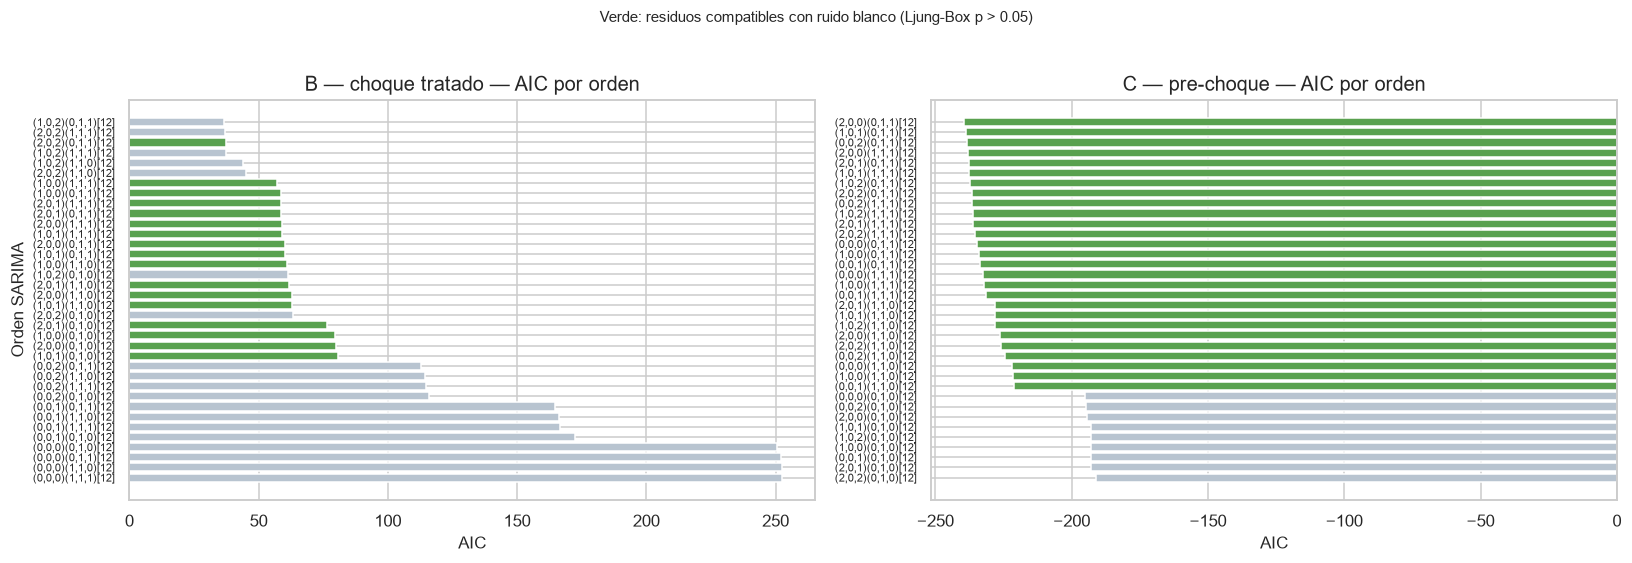

Modelos SARIMA disponibles para la evaluación: 5


In [68]:
import itertools

from statsmodels.stats.diagnostic import acorr_ljungbox

# ===========================================================================
# Malla de órdenes
# ===========================================================================
# Se mantienen fijos d = 0 y D = 1 (justificados en la sección 5.2 por la regla
# de mínima diferenciación) y se exploran los órdenes autorregresivos y de
# medias móviles alrededor de la propuesta (0,0,0)(0,1,1) de la sección 6.
#
# La malla se recorre por separado sobre DOS ventanas de entrenamiento, porque
# AIC y BIC solo son comparables entre modelos ajustados a los MISMOS datos:
#   - Ventana B: entrenamiento completo con el choque tratado (sin constante).
#   - Ventana C: entrenamiento previo al choque (con constante).
# El término de tendencia queda fijo en cada ventana según lo argumentado en la
# sección 7, de modo que la comparación aísle el efecto de los órdenes.
P_VALORES = [0, 1, 2]
Q_VALORES = [0, 1, 2]
P_EST_VALORES = [0, 1]
Q_EST_VALORES = [0, 1]

VENTANAS = {
    "B — choque tratado": (y_train_b, "n"),
    "C — pre-choque": (y_train_c, "c")
}


def ljung_box_p(ajuste, serie_y, rezagos=12):
    """p-valor de Ljung–Box sobre los residuos, excluyendo el primer ciclo
    estacional y las posiciones sin observación."""
    residuos = pd.Series(np.asarray(ajuste.resid), index=serie_y.index)
    residuos = residuos[serie_y.notna()].iloc[rezagos:]
    if len(residuos) <= rezagos:
        return np.nan
    return float(
        acorr_ljungbox(residuos, lags=[rezagos], return_df=True)["lb_pvalue"].iloc[0]
    )


def recorrer_malla(serie_y, trend, etiqueta):
    filas = []
    combinaciones = list(itertools.product(
        P_VALORES, Q_VALORES, P_EST_VALORES, Q_EST_VALORES
    ))
    for p, q, P, Q in combinaciones:
        try:
            ajuste = SARIMAX(
                serie_y,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, PERIODO_ESTACIONAL),
                trend=trend
            ).fit(disp=False)
            filas.append({
                "Ventana": etiqueta,
                "Orden": f"({p},0,{q})({P},1,{Q})[12]",
                "p": p, "q": q, "P": P, "Q": Q,
                "Parámetros": int(len(ajuste.params)),
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "sigma²": ajuste.params["sigma2"],
                "Ljung-Box p": ljung_box_p(ajuste, serie_y),
                "_ajuste": ajuste
            })
        except Exception as error:                        # noqa: BLE001
            filas.append({
                "Ventana": etiqueta,
                "Orden": f"({p},0,{q})({P},1,{Q})[12]",
                "p": p, "q": q, "P": P, "Q": Q,
                "Parámetros": np.nan, "AIC": np.nan, "BIC": np.nan,
                "sigma²": np.nan, "Ljung-Box p": np.nan,
                "_ajuste": None
            })
    print(f"  {etiqueta}: {len(combinaciones)} combinaciones ajustadas")
    return filas


TOTAL_ORDENES = (len(P_VALORES) * len(Q_VALORES)
                 * len(P_EST_VALORES) * len(Q_EST_VALORES))
print(f"Recorriendo la malla ({TOTAL_ORDENES} órdenes por ventana)...")

registros = []
for etiqueta, (serie_y, trend) in VENTANAS.items():
    registros += recorrer_malla(serie_y, trend, etiqueta)

malla = pd.DataFrame(registros)
ajustes_malla = {
    (fila["Ventana"], fila["Orden"]): fila["_ajuste"]
    for _, fila in malla.iterrows()
}
malla = malla.drop(columns="_ajuste")

# ===========================================================================
# Resultados por ventana
# ===========================================================================
COLUMNAS = ["Orden", "Parámetros", "AIC", "BIC", "sigma²", "Ljung-Box p"]

for etiqueta in VENTANAS:
    bloque = malla.loc[malla["Ventana"] == etiqueta].dropna(subset=["AIC"])
    mejores = bloque.nsmallest(5, "AIC")[COLUMNAS].set_index("Orden")
    print(f"\n{'=' * 72}\n{etiqueta} — cinco mejores órdenes por AIC\n{'=' * 72}")
    display(mejores)

    ruido_blanco = bloque.loc[bloque["Ljung-Box p"] > 0.05]
    print(f"Órdenes con residuos compatibles con ruido blanco "
          f"(Ljung-Box p > 0.05): {len(ruido_blanco)} de {len(bloque)}")
    if len(ruido_blanco):
        elegido = ruido_blanco.nsmallest(1, "AIC")
        print(f"  Mejor de ellos por AIC: {elegido['Orden'].iloc[0]}  "
              f"(AIC = {elegido['AIC'].iloc[0]:.2f}, "
              f"Ljung-Box p = {elegido['Ljung-Box p'].iloc[0]:.3f})")

    propuesto = bloque.loc[bloque["Orden"] == "(0,0,0)(0,1,1)[12]"]
    if len(propuesto):
        posicion = int((bloque["AIC"] < propuesto["AIC"].iloc[0]).sum()) + 1
        print(f"  El orden propuesto en §6, (0,0,0)(0,1,1)[12], ocupa la "
              f"posición {posicion} de {len(bloque)} por AIC "
              f"(AIC = {propuesto['AIC'].iloc[0]:.2f})")

# ===========================================================================
# Modelos seleccionados por la malla
# ===========================================================================
# Criterio: menor AIC entre los órdenes cuyos residuos superan Ljung-Box; si
# ninguno lo supera, se toma el de menor AIC y se deja constancia de que la
# especificación no alcanza residuos de ruido blanco.
seleccionados = {}
for etiqueta in VENTANAS:
    bloque = malla.loc[malla["Ventana"] == etiqueta].dropna(subset=["AIC"])
    candidatos_lb = bloque.loc[bloque["Ljung-Box p"] > 0.05]
    fuente = candidatos_lb if len(candidatos_lb) else bloque
    fila = fuente.nsmallest(1, "AIC").iloc[0]
    seleccionados[etiqueta] = {
        "Orden": fila["Orden"],
        "AIC": fila["AIC"],
        "BIC": fila["BIC"],
        "Ljung-Box p": fila["Ljung-Box p"],
        "Residuos ruido blanco": bool(fila["Ljung-Box p"] > 0.05),
        "Ajuste": ajustes_malla[(etiqueta, fila["Orden"])]
    }

resumen_seleccion = pd.DataFrame({
    etiqueta: {k: v for k, v in datos.items() if k != "Ajuste"}
    for etiqueta, datos in seleccionados.items()
})

print(f"\n{'=' * 72}\nÓrdenes seleccionados por la malla\n{'=' * 72}")
display(resumen_seleccion)

# ===========================================================================
# Comparación visual del AIC sobre la malla
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, etiqueta in zip(axes, VENTANAS):
    bloque = malla.loc[malla["Ventana"] == etiqueta].dropna(subset=["AIC"])
    bloque = bloque.sort_values("AIC")
    colores = ["#59A14F" if lb > 0.05 else "#B8C4D0"
               for lb in bloque["Ljung-Box p"]]
    ax.barh(bloque["Orden"], bloque["AIC"], color=colores)
    ax.invert_yaxis()
    ax.set(title=f"{etiqueta} — AIC por orden", xlabel="AIC")
    ax.tick_params(axis="y", labelsize=7)
axes[0].set_ylabel("Orden SARIMA")
fig.suptitle("Verde: residuos compatibles con ruido blanco (Ljung-Box p > 0.05)",
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# Los ajustes de la malla quedan disponibles para las secciones 9 y 11.
modelos_sarima.update({
    f"Malla {etiqueta} · {datos['Orden']}": datos["Ajuste"]
    for etiqueta, datos in seleccionados.items()
})
print(f"Modelos SARIMA disponibles para la evaluación: {len(modelos_sarima)}")

La búsqueda deja ver que...

## 9. Análisis de residuos y métricas AIC / BIC

Un modelo bien especificado deja residuos sin autocorrelación (ruido blanco). Se
revisan la ACF de los residuos, la prueba de Ljung–Box y su distribución.

Parámetros  \
Ventana                          Modelo                                  
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c                 3   
                                 M2 (2,0,0)(0,1,1)+c                 5   
                                 M3 (0,1,1)(0,1,1) airline           3   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c                 3   
                                 M2 (2,0,0)(0,1,1)+c                 5   
                                 M3 (0,1,1)(0,1,1) airline           3   

                                                            Residuos usados  \
Ventana                          Modelo                                       
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c                    130   
                                 M2 (2,0,0)(0,1,1)+c                    130   
                                 M3 (0,1,1)(0,1,1) airline              129   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c                    122   
                                 M2 (2,0,0)(0,1,1)+c                    122   
                                 M3 (0,1,1)(0,1,1) airline              121   

                                                               AIC     BIC  \
Ventana                          Modelo                                      
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c        252.91  261.63   
                                 M2 (2,0,0)(0,1,1)+c         61.86   76.38   
                                 M3 (0,1,1)(0,1,1) airline   61.01   69.70   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c       -234.64 -226.23   
                                 M2 (2,0,0)(0,1,1)+c       -239.54 -225.52   
                                 M3 (0,1,1)(0,1,1) airline -234.79 -226.41   

                                                            sigma²  \
Ventana                          Modelo                              
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c          0.39   
                                 M2 (2,0,0)(0,1,1)+c          0.08   
                                 M3 (0,1,1)(0,1,1) airline    0.08   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c          0.01   
                                 M2 (2,0,0)(0,1,1)+c          0.01   
                                 M3 (0,1,1)(0,1,1) airline    0.01   

                                                            Ljung-Box p (12)  \
Ventana                          Modelo                                        
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c                    0.00   
                                 M2 (2,0,0)(0,1,1)+c                    0.73   
                                 M3 (0,1,1)(0,1,1) airline              0.61   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c                    0.14   
                                 M2 (2,0,0)(0,1,1)+c                    0.98   
                                 M3 (0,1,1)(0,1,1) airline              0.95   

                                                            Ljung-Box p (24)  \
Ventana                          Modelo                                        
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c                    0.00   
                                 M2 (2,0,0)(0,1,1)+c                    1.00   
                                 M3 (0,1,1)(0,1,1) airline              0.99   
C — pre-choque (2009-01→2020-02) M1 (0,0,0)(0,1,1)+c                    0.17   
                                 M2 (2,0,0)(0,1,1)+c                    0.91   
                                 M3 (0,1,1)(0,1,1) airline              0.64   

                                                            Jarque-Bera p  \
Ventana                          Modelo                                     
B — completa (2009-01→2021-03)   M1 (0,0,0)(0,1,1)+c                 0.00   
                                 M2 (2,0,0)(0,1,1)+c                 0.00   
                                 M3 (0,1,1)(0,1,1) airline

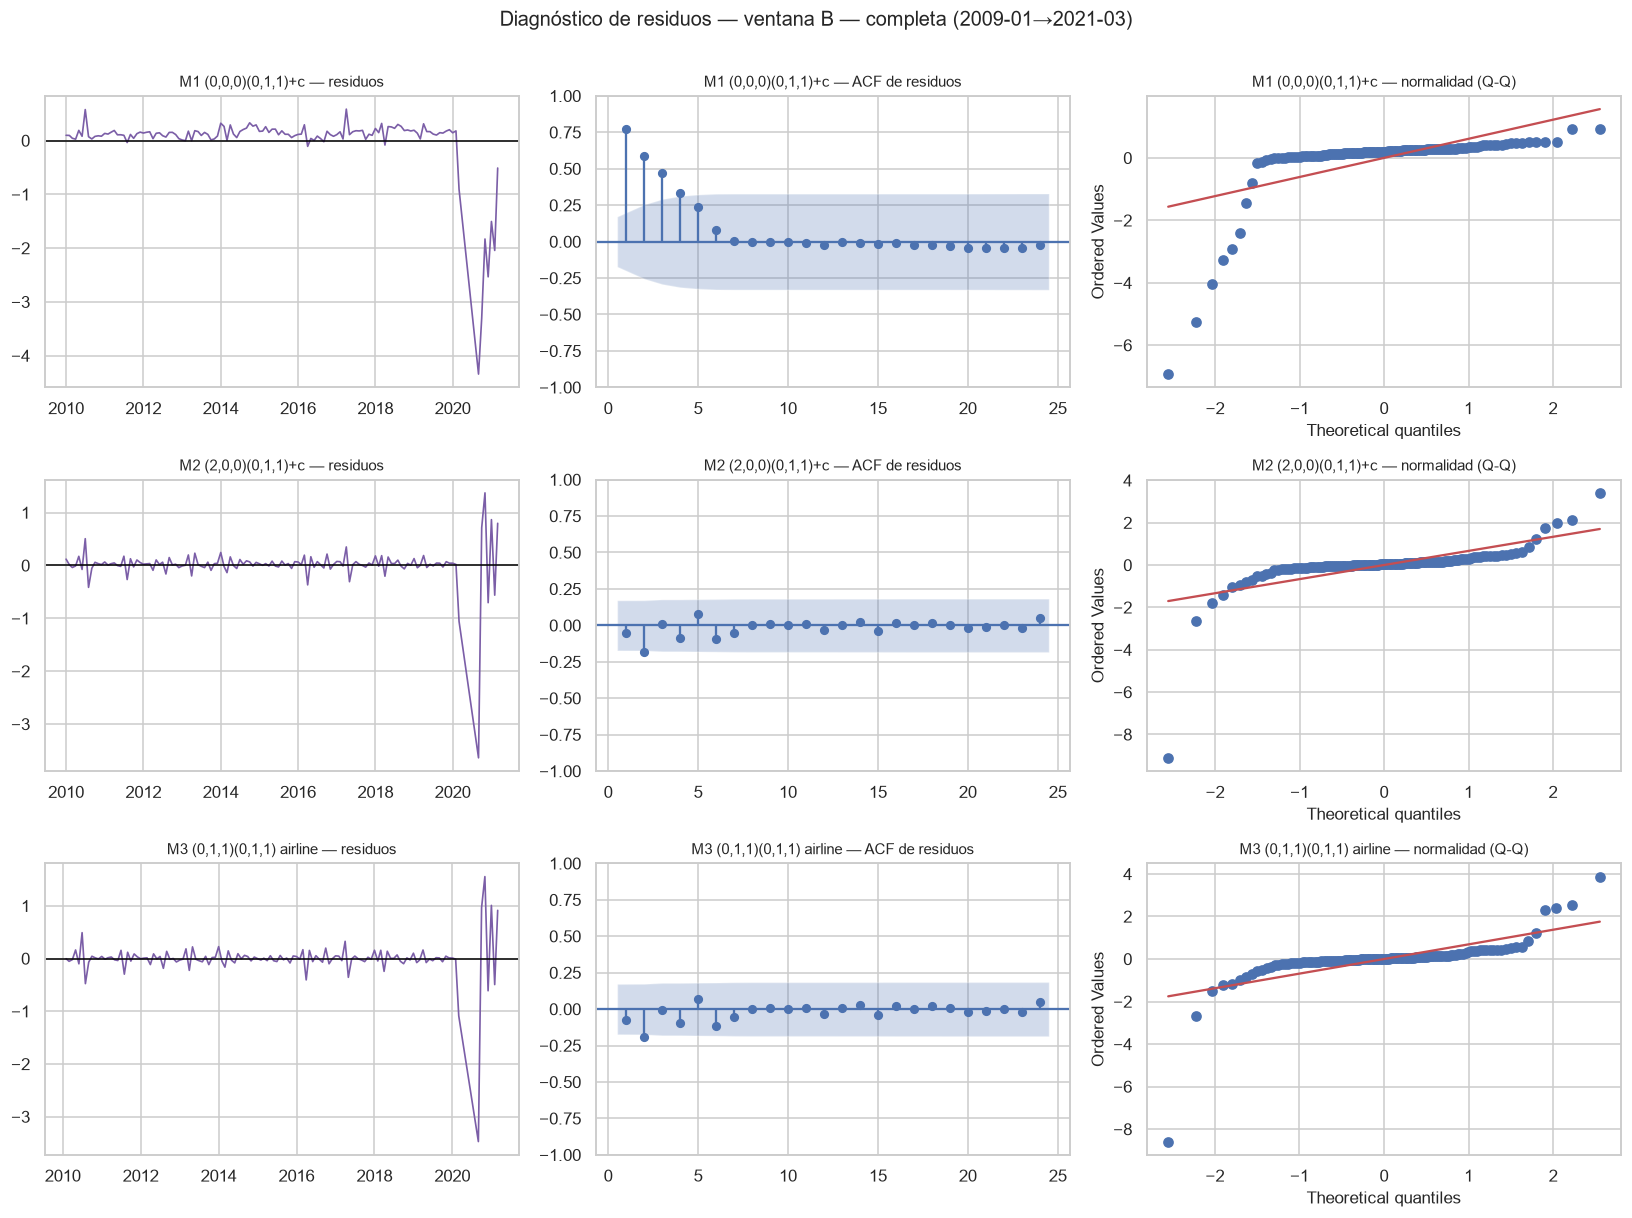

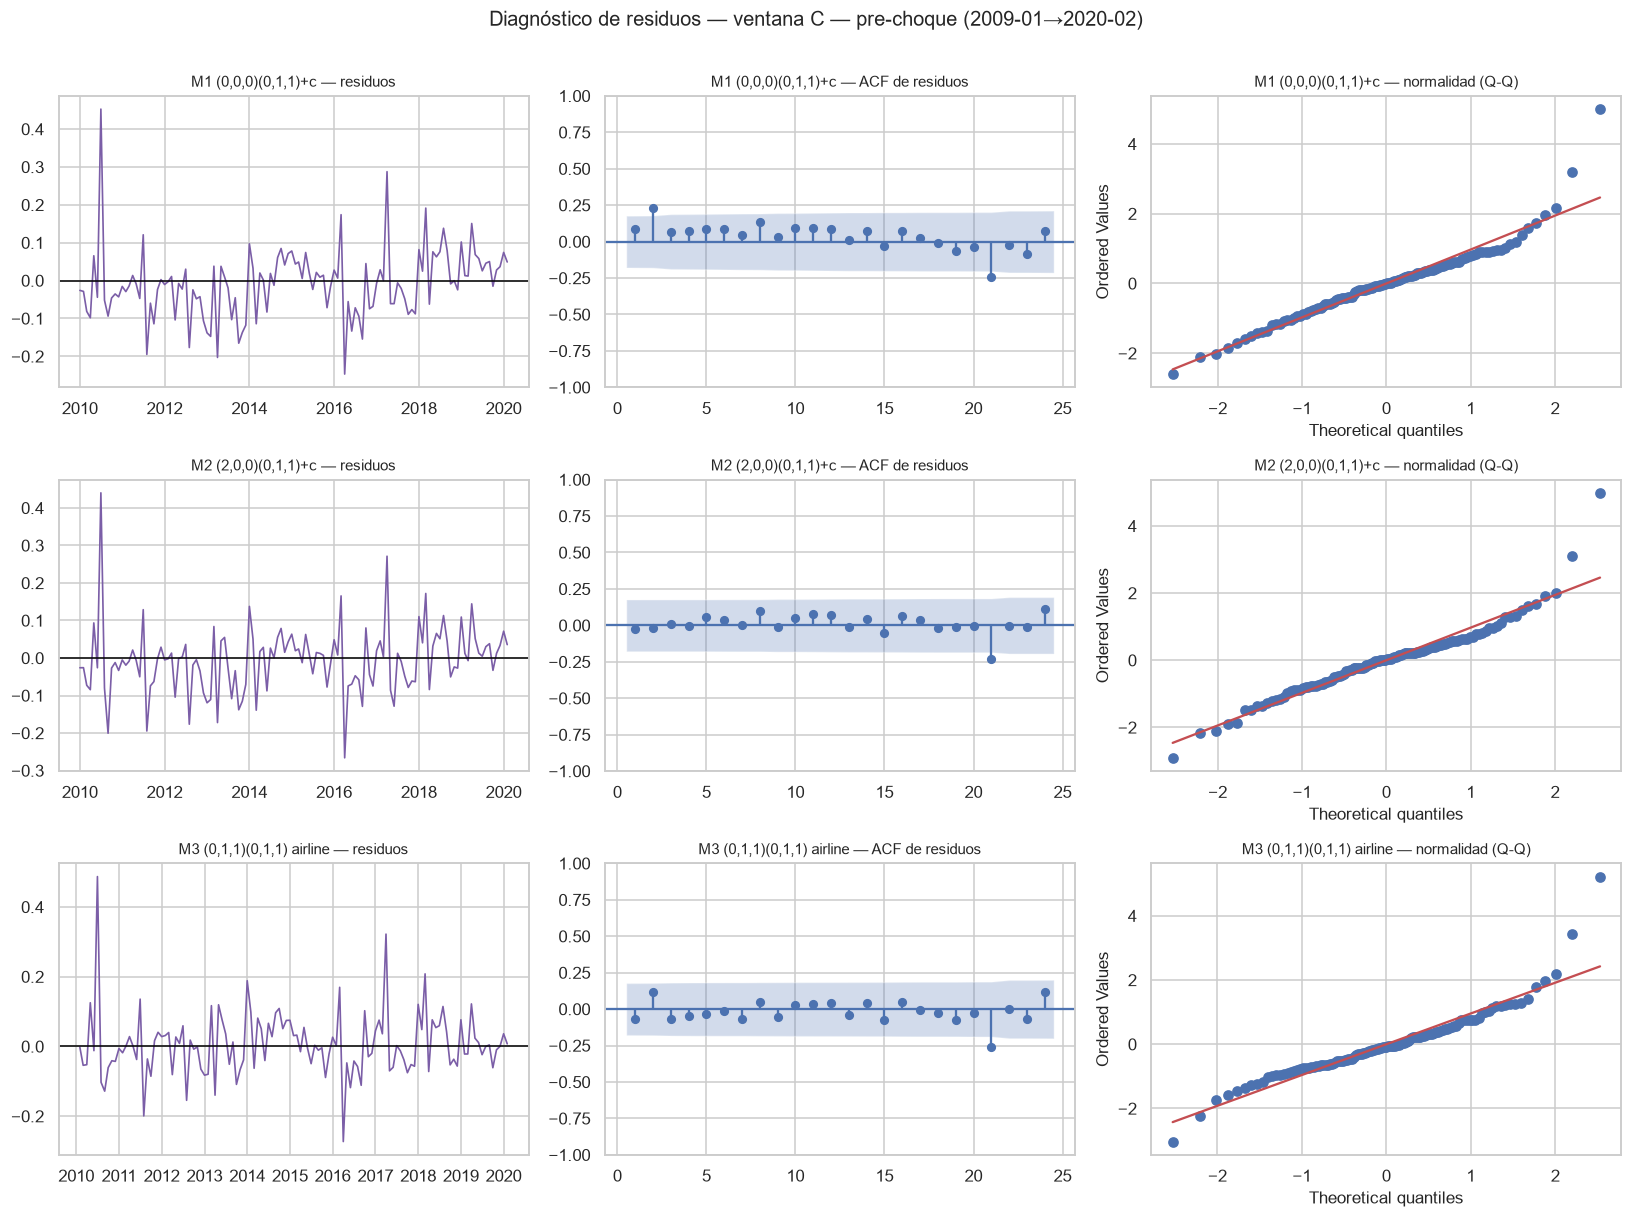

Selección por ventana

B — completa (2009-01→2021-03)
  Modelos con residuos de ruido blanco: 2 de 3
  Seleccionado: M3 (0,1,1)(0,1,1) airline
    AIC = 61.01   BIC = 69.70   sigma² = 0.0838
    Ljung-Box p: 0.613 (12) / 0.989 (24)

C — pre-choque (2009-01→2020-02)
  Modelos con residuos de ruido blanco: 3 de 3
  Seleccionado: M2 (2,0,0)(0,1,1)+c
    AIC = -239.54   BIC = -225.52   sigma² = 0.0069
    Ljung-Box p: 0.985 (12) / 0.907 (24)

Modelos disponibles para la evaluación sobre prueba: 6


In [69]:
from scipy import stats

# ===========================================================================
# Tres especificaciones a contrastar
# ===========================================================================
# M1 — orden identificado visualmente en la sección 6 a partir de ACF y PACF.
# M2 — orden seleccionado por la malla de la sección 8 según AIC.
# M3 — modelo "airline" (0,1,1)(0,1,1)[12], referencia clásica de Box y Jenkins
#      para series mensuales con tendencia y estacionalidad. Sirve de contraste:
#      incorpora la diferencia regular que la sección 5 descartó por
#      sobre-diferenciación, de modo que permite verificar esa decisión.
ESPECIFICACIONES = {
    "M1 (0,0,0)(0,1,1)+c": {"order": (0, 0, 0), "seasonal_order": (0, 1, 1, 12),
                            "trend": "c"},
    "M2 (2,0,0)(0,1,1)+c": {"order": (2, 0, 0), "seasonal_order": (0, 1, 1, 12),
                            "trend": "c"},
    "M3 (0,1,1)(0,1,1) airline": {"order": (0, 1, 1),
                                  "seasonal_order": (0, 1, 1, 12),
                                  "trend": "n"}
}

# AIC y BIC solo son comparables entre modelos ajustados a los MISMOS datos, por
# lo que cada ventana se analiza como un bloque independiente.
VENTANAS_RESIDUOS = {
    "B — completa (2009-01→2021-03)": y_train_b,
    "C — pre-choque (2009-01→2020-02)": y_train_c
}


def observaciones_consumidas(cfg):
    """Número de residuos iniciales que NO son informativos.

    La diferenciación consume d + D*s observaciones; sobre ellas el filtro de
    Kalman devuelve residuos de inicialización difusa, de magnitud arbitraria.
    Conservarlos infla la varianza muestral y encoge artificialmente todas las
    autocorrelaciones normalizadas, lo que produce p-valores de Ljung-Box
    espuriamente altos."""
    d = cfg["order"][1]
    D, s = cfg["seasonal_order"][1], cfg["seasonal_order"][3]
    return d + D * s


def residuos_limpios(ajuste, serie_y, cfg):
    """Residuos excluyendo la inicialización y las posiciones sin observación."""
    residuos = pd.Series(np.asarray(ajuste.resid), index=serie_y.index)
    return residuos[serie_y.notna()].iloc[observaciones_consumidas(cfg):]


ajustes_residuos = {}
diagnosticos = []

for nombre_ventana, serie_y in VENTANAS_RESIDUOS.items():
    for nombre_modelo, cfg in ESPECIFICACIONES.items():
        ajuste = SARIMAX(serie_y, **cfg).fit(disp=False)
        ajustes_residuos[(nombre_ventana, nombre_modelo)] = ajuste

        res = residuos_limpios(ajuste, serie_y, cfg)
        lb = acorr_ljungbox(res, lags=[12, 24], return_df=True)["lb_pvalue"]
        _, p_jb = stats.jarque_bera(res)

        # Homocedasticidad: razón de varianzas entre el último y el primer
        # tercio de los residuos (prueba de cambio de varianza de statsmodels).
        h_stat, p_h = ajuste.test_heteroskedasticity("breakvar")[0]

        diagnosticos.append({
            "Ventana": nombre_ventana,
            "Modelo": nombre_modelo,
            "Parámetros": int(len(ajuste.params)),
            "Residuos usados": len(res),
            "AIC": ajuste.aic,
            "BIC": ajuste.bic,
            "sigma²": ajuste.params["sigma2"],
            "Ljung-Box p (12)": float(lb.iloc[0]),
            "Ljung-Box p (24)": float(lb.iloc[1]),
            "Jarque-Bera p": float(p_jb),
            "Heteroced. p": float(p_h),
            "Asimetría": float(stats.skew(res)),
            "Curtosis": float(stats.kurtosis(res, fisher=False))
        })

diagnostico = pd.DataFrame(diagnosticos).set_index(["Ventana", "Modelo"])
diagnostico["Ruido blanco"] = (
    (diagnostico["Ljung-Box p (12)"] > 0.05)
    & (diagnostico["Ljung-Box p (24)"] > 0.05)
)

display(diagnostico)

# ===========================================================================
# Gráficos de residuos: serie, ACF y normalidad
# ===========================================================================
for nombre_ventana, serie_y in VENTANAS_RESIDUOS.items():
    fig, axes = plt.subplots(3, 3, figsize=(15, 11))
    for fila, nombre_modelo in enumerate(ESPECIFICACIONES):
        ajuste = ajustes_residuos[(nombre_ventana, nombre_modelo)]
        res = residuos_limpios(ajuste, serie_y, ESPECIFICACIONES[nombre_modelo])
        estandar = (res - res.mean()) / res.std()

        axes[fila, 0].plot(res, color="#7B5EA7", lw=1.1)
        axes[fila, 0].axhline(0, color="black", lw=1)
        axes[fila, 0].set_title(f"{nombre_modelo} — residuos", fontsize=10)

        plot_acf(res, lags=24, ax=axes[fila, 1], zero=False)
        axes[fila, 1].set_title(f"{nombre_modelo} — ACF de residuos", fontsize=10)

        stats.probplot(estandar, dist="norm", plot=axes[fila, 2])
        axes[fila, 2].set_title(f"{nombre_modelo} — normalidad (Q-Q)", fontsize=10)

    fig.suptitle(f"Diagnóstico de residuos — ventana {nombre_ventana}",
                 y=1.005, fontsize=13)
    plt.tight_layout()
    plt.show()

# ===========================================================================
# Selección del mejor modelo por ventana
# ===========================================================================
# Criterio, en este orden:
#   1. Residuos compatibles con ruido blanco (Ljung-Box p > 0.05 en 12 y 24).
#      Un modelo con residuos autocorrelacionados deja estructura sin explotar,
#      y su AIC no es interpretable como medida de ajuste adecuado.
#   2. Entre los que cumplen, menor AIC dentro de la misma ventana.
print("=" * 72)
print("Selección por ventana")
print("=" * 72)

mejores_por_ventana = {}
for nombre_ventana in VENTANAS_RESIDUOS:
    bloque = diagnostico.loc[nombre_ventana]
    validos = bloque.loc[bloque["Ruido blanco"]]
    fuente = validos if len(validos) else bloque
    nombre_mejor = fuente["AIC"].idxmin()

    mejores_por_ventana[nombre_ventana] = nombre_mejor
    fila = bloque.loc[nombre_mejor]
    print(f"\n{nombre_ventana}")
    print(f"  Modelos con residuos de ruido blanco: {int(bloque['Ruido blanco'].sum())} de 3")
    print(f"  Seleccionado: {nombre_mejor}")
    print(f"    AIC = {fila['AIC']:.2f}   BIC = {fila['BIC']:.2f}   "
          f"sigma² = {fila['sigma²']:.4f}")
    print(f"    Ljung-Box p: {fila['Ljung-Box p (12)']:.3f} (12) / "
          f"{fila['Ljung-Box p (24)']:.3f} (24)")
    if not fila["Ruido blanco"]:
        print("    ADVERTENCIA: ningún modelo de esta ventana alcanza residuos "
              "de ruido blanco.")

# Los seis ajustes quedan disponibles para la evaluación de la sección 11.
modelos_finales = {
    f"{nombre_modelo} · {nombre_ventana.split(' —')[0]}": ajuste
    for (nombre_ventana, nombre_modelo), ajuste in ajustes_residuos.items()
}
print(f"\nModelos disponibles para la evaluación sobre prueba: "
      f"{len(modelos_finales)}")

Estos resultados dejan ver...

## 10. Modelos alternativos: Prophet, Holt-Winters, suavizamiento exponencial y seasonal naive

El *seasonal naive* funciona como línea base: cualquier modelo que no lo supere no
está aportando valor.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# ===========================================================================
# Preparación
# ===========================================================================
# Prophet no está disponible en el entorno. El enunciado admite cualquiera de
# las alternativas, de modo que se implementan las tres restantes: seasonal
# naive, suavizamiento exponencial simple y Holt-Winters (en sus variantes de
# tendencia lineal y amortiguada).
#
# Todos los métodos se aplican sobre log1p y se retransforman con expm1, igual
# que los modelos SARIMA, para que la comparación de la sección 11 sea directa.
#
# Holt-Winters y el suavizamiento exponencial no admiten valores faltantes. En
# la ventana B los cinco meses de cierre se interpolan linealmente en escala
# logarítmica; queda constancia porque es un tratamiento distinto al que recibe
# SARIMAX, que sí maneja los faltantes de forma nativa.
y_train_b_interp = y_train_b.interpolate(method="linear")

VENTANAS_ALT = {
    "B": {"y": y_train_b_interp, "fin": serie_train.index.max()},
    "C": {"y": y_train_c, "fin": serie_pre_choque.index.max()}
}

print(f"Ventana B: {len(y_train_b_interp)} meses "
      f"({int(y_train_b.isna().sum())} interpolados)")
print(f"Ventana C: {len(y_train_c)} meses (sin faltantes)")


def alinear_pronostico(valores_log, fin_entrenamiento):
    """Retransforma a nivel y recorta al índice del conjunto de prueba."""
    horizonte = pd.date_range(
        fin_entrenamiento, serie_test.index.max(), freq="MS"
    )[1:]
    serie = pd.Series(np.expm1(np.asarray(valores_log)[:len(horizonte)]),
                      index=horizonte)
    return serie.reindex(serie_test.index)


# ===========================================================================
# 1. Seasonal naive — línea base
# ===========================================================================
# El pronóstico de cada mes es el valor observado en ese mismo mes durante el
# último año de entrenamiento. Es la referencia mínima: cualquier modelo que no
# la supere no está aportando información.
def seasonal_naive(y_log, fin_entrenamiento):
    ultimo_ciclo = np.asarray(y_log)[-PERIODO_ESTACIONAL:]
    horizonte = len(pd.date_range(fin_entrenamiento, serie_test.index.max(),
                                  freq="MS")[1:])
    repetido = [ultimo_ciclo[i % PERIODO_ESTACIONAL] for i in range(horizonte)]
    return alinear_pronostico(repetido, fin_entrenamiento)


# ===========================================================================
# 2, 3 y 4. Suavizamiento exponencial y Holt-Winters
# ===========================================================================
CONFIGS_SUAVIZAMIENTO = {
    "Suavizamiento exp. simple": {"tipo": "ses"},
    "Holt-Winters aditivo": {
        "tipo": "hw", "trend": "add", "seasonal": "add", "damped_trend": False
    },
    "Holt-Winters amortiguado": {
        "tipo": "hw", "trend": "add", "seasonal": "add", "damped_trend": True
    }
}

modelos_alternativos = {}
resumen_alternativos = []

for ventana, cfg_ventana in VENTANAS_ALT.items():
    y_log, fin = cfg_ventana["y"], cfg_ventana["fin"]
    horizonte = len(pd.date_range(fin, serie_test.index.max(), freq="MS")[1:])

    # Seasonal naive
    pron = seasonal_naive(y_log, fin)
    modelos_alternativos[f"Seasonal naive · {ventana}"] = pron
    resumen_alternativos.append({
        "Ventana": ventana, "Método": "Seasonal naive",
        "Parámetros": 0, "AIC": np.nan,
        "Pronóstico medio": pron.mean()
    })

    for nombre, cfg in CONFIGS_SUAVIZAMIENTO.items():
        if cfg["tipo"] == "ses":
            ajuste = SimpleExpSmoothing(
                y_log, initialization_method="estimated"
            ).fit()
        else:
            ajuste = ExponentialSmoothing(
                y_log,
                trend=cfg["trend"],
                seasonal=cfg["seasonal"],
                seasonal_periods=PERIODO_ESTACIONAL,
                damped_trend=cfg["damped_trend"],
                initialization_method="estimated"
            ).fit()

        pron = alinear_pronostico(ajuste.forecast(horizonte), fin)
        modelos_alternativos[f"{nombre} · {ventana}"] = pron
        resumen_alternativos.append({
            "Ventana": ventana, "Método": nombre,
            "Parámetros": int(np.sum(~np.isnan(ajuste.params_formatted["param"]
                                               .astype(float).values))),
            "AIC": ajuste.aic,
            "Pronóstico medio": pron.mean()
        })

resumen = pd.DataFrame(resumen_alternativos).set_index(["Ventana", "Método"])
display(resumen)

print(f"\nMedia real del conjunto de prueba: {serie_test.mean():,.0f} visitantes/mes")
print("\nNota: el AIC de los métodos de suavizamiento NO es comparable con el de")
print("los modelos SARIMA (distinta verosimilitud y distinto número efectivo de")
print("observaciones). La comparación válida se hace sobre el conjunto de prueba")
print("en la sección 11.")

# ===========================================================================
# Visualización de los pronósticos
# ===========================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

for ax, ventana in zip(axes, VENTANAS_ALT):
    ax.plot(serie_train, color="#B8C4D0", lw=1.1, label="Entrenamiento")
    ax.plot(serie_test, color="#222222", lw=1.8, label="Prueba (real)")
    for nombre, pron in modelos_alternativos.items():
        if nombre.endswith(f"· {ventana}"):
            ax.plot(pron, lw=1.3, ls="--", label=nombre.replace(f" · {ventana}", ""))
    ax.axvline(FECHA_CORTE, color="black", ls=":", lw=1.2)
    ax.set(title=f"Modelos alternativos — ventana {ventana}", ylabel="Visitantes")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

print(f"Modelos alternativos generados: {len(modelos_alternativos)}")

El desempeño de los modelos alternativos indica que...

## 11. Comparación de todos los modelos

**Nota metodológica:** AIC y BIC solo son comparables **dentro** de la familia
ARIMA/SARIMA, porque dependen de la verosimilitud del mismo tipo de modelo. Frente
a Prophet, Holt-Winters o seasonal naive la comparación debe hacerse únicamente con
métricas de error sobre el conjunto de prueba (MAE, RMSE, MAPE).

In [ ]:
# ===========================================================================
# Recolección de todos los pronósticos sobre el conjunto de prueba
# ===========================================================================
# Los modelos se agrupan en dos CATEGORÍAS según la ventana de entrenamiento:
#
#   B — Partición 70/30 completa (2009-01 → 2021-03). Es la que exige el
#       enunciado; su entrenamiento incluye el choque sanitario.
#   C — Corte previo al choque (2009-01 → 2020-02). Subconjunto del mismo
#       entrenamiento, sin datos de prueba, con trece meses menos.
#
# Ambas categorías pronostican EXACTAMENTE el mismo conjunto de prueba
# (2021-04 → 2026-06, 63 meses), de modo que las métricas son comparables.
FIN_VENTANA = {
    "B": serie_train.index.max(),
    "C": serie_pre_choque.index.max()
}


def pronostico_sarimax(ajuste, ventana):
    """Pronóstico en nivel, alineado al índice del conjunto de prueba."""
    horizonte = pd.date_range(
        FIN_VENTANA[ventana], serie_test.index.max(), freq="MS"
    )[1:]
    prediccion = np.expm1(ajuste.get_forecast(len(horizonte)).predicted_mean)
    prediccion.index = horizonte
    return prediccion.reindex(serie_test.index)


pronosticos = {
    nombre: pronostico_sarimax(ajuste, nombre.split(" · ")[1])
    for nombre, ajuste in modelos_finales.items()
}
pronosticos.update(modelos_alternativos)

print(f"Pronósticos a evaluar: {len(pronosticos)}")
print(f"Horizonte: {serie_test.index.min():%Y-%m} a {serie_test.index.max():%Y-%m} "
      f"({len(serie_test)} meses)")


# ===========================================================================
# Métricas de error
# ===========================================================================
def metricas(real, prediccion):
    error = real - prediccion
    return {
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "MAPE %": (error.abs() / real).mean() * 100
    }


def familia(nombre):
    if nombre.split()[0] in {"M1", "M2", "M3"}:
        return "SARIMA"
    if "naive" in nombre.lower():
        return "Línea base"
    return "Suavizamiento"


filas = []
for nombre, prediccion in pronosticos.items():
    ventana = nombre.split(" · ")[1]
    filas.append({
        "Categoría": f"{ventana} — {'70/30 completa' if ventana == 'B' else 'corte pre-choque'}",
        "Familia": familia(nombre),
        "Modelo": nombre.split(" · ")[0],
        **metricas(serie_test, prediccion),
        "Pronóstico medio": prediccion.mean()
    })

comparacion = pd.DataFrame(filas)

# Habilidad relativa: reducción porcentual del RMSE frente al seasonal naive
# entrenado sobre la MISMA ventana. Valores positivos indican que el modelo
# aporta información por encima de repetir el último ciclo observado.
rmse_naive = (
    comparacion.loc[comparacion["Familia"] == "Línea base"]
               .set_index("Categoría")["RMSE"]
)
comparacion["Mejora vs naive %"] = comparacion.apply(
    lambda f: 100 * (1 - f["RMSE"] / rmse_naive[f["Categoría"]]), axis=1
)

comparacion = (
    comparacion.set_index(["Categoría", "Familia", "Modelo"])
               .sort_index()
               .sort_values("RMSE")
)

print("\n" + "=" * 72)
print("Comparación global sobre el conjunto de prueba")
print("=" * 72)
display(comparacion)

# ===========================================================================
# Resumen por categoría
# ===========================================================================
resumen_categoria = (
    comparacion.reset_index()
               .groupby("Categoría")
               .agg(Modelos=("RMSE", "size"),
                    RMSE_mejor=("RMSE", "min"),
                    RMSE_mediano=("RMSE", "median"),
                    RMSE_peor=("RMSE", "max"))
)
print("\nDesempeño por categoría de entrenamiento:")
display(resumen_categoria)

print(f"Media real del conjunto de prueba: {serie_test.mean():,.0f} visitantes/mes")

# ===========================================================================
# Gráficos comparativos
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

orden = comparacion.reset_index().sort_values("RMSE")
etiquetas = [f"{f['Modelo']} [{f['Categoría'][0]}]" for _, f in orden.iterrows()]
colores_familia = {"SARIMA": "#4C78A8", "Suavizamiento": "#F28E2B",
                   "Línea base": "#9E9E9E"}
axes[0].barh(etiquetas, orden["RMSE"],
             color=[colores_familia[f] for f in orden["Familia"]])
axes[0].invert_yaxis()
axes[0].set(title="RMSE sobre el conjunto de prueba", xlabel="RMSE")
axes[0].tick_params(axis="y", labelsize=8)

for categoria, marca in [("B", "o"), ("C", "s")]:
    sub = orden.loc[orden["Categoría"].str.startswith(categoria)]
    axes[1].scatter(sub["RMSE"], sub["MAPE %"], s=70, marker=marca,
                    label=f"Ventana {categoria}",
                    color=[colores_familia[f] for f in sub["Familia"]])
axes[1].set(title="RMSE frente a MAPE", xlabel="RMSE", ylabel="MAPE (%)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ===========================================================================
# Trayectorias de los mejores de cada categoría
# ===========================================================================
mejores = (
    comparacion.reset_index()
               .sort_values("RMSE")
               .groupby("Categoría")
               .head(2)
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_train.loc["2017":], color="#B8C4D0", lw=1.2, label="Entrenamiento")
ax.plot(serie_test, color="#222222", lw=2, label="Prueba (real)")
for _, fila in mejores.iterrows():
    clave = f"{fila['Modelo']} · {fila['Categoría'][0]}"
    ax.plot(pronosticos[clave], lw=1.4, ls="--",
            label=f"{fila['Modelo']} [{fila['Categoría'][0]}]")
ax.axvline(FECHA_CORTE, color="black", ls=":", lw=1.2)
ax.set(title="Dos mejores modelos de cada categoría frente al valor real",
       xlabel="Fecha", ylabel="Visitantes")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

La comparación global muestra que...

### 11.1 Métricas por sub-período

El RMSE global es engañoso en esta serie: el entrenamiento termina en el piso
pandémico (marzo 2021) y la prueba atraviesa la recuperación. Se reportan las
métricas segmentadas para distinguir el error atribuible al cambio de régimen del
error propio del modelo.

In [ ]:
# ===========================================================================
# Métricas segmentadas por sub-período
# ===========================================================================
# El horizonte de prueba atraviesa tres regímenes distintos, de modo que una
# métrica global mezcla situaciones que no son comparables entre sí:
#
#   2021 (abr–dic) : la serie sigue en el piso pandémico. Ningún modelo
#                    univariado entrenado antes del choque podía anticiparlo.
#   2022–2023      : recuperación en curso, régimen de transición.
#   2024–2026      : la serie ya retomó su dinámica estructural.
#
# El MAPE global es especialmente engañoso porque su denominador es minúsculo
# en 2021, de modo que ese tramo domina el promedio.
TRAMOS = {
    "2021 (abr–dic)": ("2021-04", "2021-12"),
    "2022–2023": ("2022-01", "2023-12"),
    "2024–2026": ("2024-01", "2026-06")
}

filas_tramo = []
for nombre, prediccion in pronosticos.items():
    modelo, ventana = nombre.split(" · ")
    registro = {"Ventana": ventana, "Familia": familia(nombre), "Modelo": modelo}
    for tramo, (inicio, fin) in TRAMOS.items():
        real_t = serie_test.loc[inicio:fin]
        pred_t = prediccion.loc[inicio:fin]
        registro[f"{tramo} · RMSE"] = np.sqrt(((real_t - pred_t) ** 2).mean())
        registro[f"{tramo} · MAPE %"] = (
            (real_t - pred_t).abs() / real_t
        ).mean() * 100
    filas_tramo.append(registro)

por_tramo = (
    pd.DataFrame(filas_tramo)
      .set_index(["Ventana", "Familia", "Modelo"])
      .sort_index()
)

display(por_tramo)

print("Media real por tramo:")
for tramo, (inicio, fin) in TRAMOS.items():
    print(f"  {tramo:16s} {serie_test.loc[inicio:fin].mean():>10,.0f} visitantes/mes")

# ===========================================================================
# Evolución del error a lo largo del horizonte
# ===========================================================================
mejor_por_ventana = {}
for ventana in ["B", "C"]:
    sub = comparacion.reset_index()
    sub = sub.loc[sub["Categoría"].str.startswith(ventana)]
    mejor_por_ventana[ventana] = sub.nsmallest(1, "RMSE")["Modelo"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(TRAMOS))
ancho = 0.35
for desplazamiento, ventana in zip([-ancho / 2, ancho / 2], ["B", "C"]):
    modelo = mejor_por_ventana[ventana]
    valores = [
        por_tramo.loc[(ventana, slice(None), modelo), f"{t} · RMSE"].iloc[0]
        for t in TRAMOS
    ]
    axes[0].bar(x + desplazamiento, valores, ancho,
                label=f"{modelo} [{ventana}]")
axes[0].set_xticks(x)
axes[0].set_xticklabels(TRAMOS.keys(), fontsize=9)
axes[0].set(title="RMSE por sub-período — mejor modelo de cada categoría",
            ylabel="RMSE")
axes[0].legend(fontsize=9)

for ventana, color in [("B", "#E15759"), ("C", "#59A14F")]:
    clave = f"{mejor_por_ventana[ventana]} · {ventana}"
    error_abs = (serie_test - pronosticos[clave]).abs()
    axes[1].plot(error_abs, color=color, lw=1.4,
                 label=f"{mejor_por_ventana[ventana]} [{ventana}]")
axes[1].axvline(INICIO_QUIEBRE, color="gray", ls="-.", lw=1.2,
                label="Quiebre de fuente 2023-01")
axes[1].set(title="Error absoluto mes a mes", xlabel="Fecha",
            ylabel="Error absoluto")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

La segmentación revela que...

### 11.2 Modelo seleccionado

Gracias al los datos podemos ver que el mejor modelo de todos es...

## 12. Predicción de los valores de la serie con el mejor modelo

Se grafican entrenamiento, prueba y pronóstico con sus intervalos de confianza.

Podemos ver que los valores...

## 13. Conclusiones

Conclusiones del análisis...